# ChatGPT 原理课堂演示（按需下载版）

这份 Notebook 根据 `GPT 讲义.md` 的主线组织，用一组可以现场修改、现场运行、现场观察的实验，把“ChatGPT 背后是什么”从抽象描述变成可见过程。

使用方式是：先读每个代码块前面的 Markdown，明确这格代码要演示的问题；运行代码后，先看输出，再读代码块后面的 Markdown，理解输出中的表格、图像和文字分别说明了什么。每一节都刻意保留了可以修改的变量，可以直接改变输入、参数或样本文本，观察“改变这里之后会发生什么”。

本 Notebook 采用“首次联网准备、后续本地复用”的方式。小型机制演示模型、TinyStories 样本文本和 Qwen 指令模型都会优先从同一文件夹下的 `gpt_lecture_assets/` 读取；如果某个资产不存在，代码会在首次用到它时从 Hugging Face 下载到本地。下载完成后，即使课堂上没有网络，也可以复用本地资产运行演示。大模型目录不应提交到 git。

输出来源分三类：第一，`Qwen/Qwen2.5-0.5B-Instruct` 的回答是真正开源指令模型生成的文本；第二，`sshleifer/tiny-gpt2` 只保留给 GPT-2 tokenizer 对比和 attention 小矩阵可视化等必须小模型才方便的机制演示；第三，BPE、bigram、RL、奖励函数、多模态 patch 等是玩具代码或手写样例，只说明原理，不假装是模型回答。

请使用 Jupyter kernel：`Python (pt)`.


## 0. 运行环境和本地资产检查

这一格是整本 Notebook 的“启动检查”。它不是在讲某个深度学习概念，而是在确认演示运行条件已经满足：Notebook 能找到或创建 `gpt_lecture_assets/`，缺失资产可以按需下载，随机种子也已经固定。

输出来源：这一节没有模型生成回答，只有本地环境、资产路径、设备和下载状态检查。

这里的重点是：真实大模型系统有很多产品层和工程层的包装，但最底层仍然要先解决“数据在哪里”“模型权重在哪里”“运行设备是什么”。这里的 `MODEL_DIR` 指向 tiny GPT-2，只用于 GPT-2 tokenizer 对比和 attention 小矩阵可视化等轻量机制演示；`ASSISTANT_MODEL_DIR` 指向 Qwen2.5-0.5B-Instruct，用于后面真正生成助手回答；`DATA_PATH` 指向 TinyStories 样本文本。

可以改的地方：如果文件夹被改名或移动，通常不需要改代码，因为 `find_asset_dir()` 会自动找；如果确实找不到，可以把 `ASSET_DIR` 手动改成实际路径。`DOWNLOAD_MISSING_ASSETS=True` 表示缺资产时允许联网下载；如果课堂现场没有网络，应提前运行一次 Notebook 完成下载。


In [1]:
# 这格代码分为五步：
# 1) 导入后续所有演示需要的库，包括数据处理、绘图、PyTorch、Transformers 和 Hugging Face 下载工具。
# 2) 自动寻找或创建同文件夹、w8 目录或仓库根目录下的 gpt_lecture_assets。
# 3) 如果 tiny GPT-2 或 TinyStories 样本文本不存在，就下载到本地资产目录。
# 4) 定义后面真实助手回答会用到的 Qwen 指令模型加载和生成函数。
# 5) 固定随机种子，并打印当前资产状态。

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import ast
import json
import math
import operator
import random
import re
import textwrap
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import hf_hub_download, snapshot_download
from IPython.display import Markdown, display
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()

START_DIR = Path.cwd()
DOWNLOAD_MISSING_ASSETS = True

TINY_MODEL_REPO = "sshleifer/tiny-gpt2"
TINY_MODEL_DIRNAME = "sshleifer_tiny_gpt2"
TINY_REQUIRED_FILES = [
    "config.json",
    "pytorch_model.bin",
    "tokenizer_config.json",
    "vocab.json",
    "merges.txt",
]
TINY_ALLOW_PATTERNS = TINY_REQUIRED_FILES + ["special_tokens_map.json"]

ASSISTANT_MODEL_REPO = "Qwen/Qwen2.5-0.5B-Instruct"
ASSISTANT_MODEL_DIRNAME = "qwen2_5_0_5b_instruct"
ASSISTANT_REQUIRED_FILES = [
    "config.json",
    "generation_config.json",
    "model.safetensors",
    "tokenizer.json",
    "tokenizer_config.json",
    "vocab.json",
    "merges.txt",
]
ASSISTANT_ALLOW_PATTERNS = ASSISTANT_REQUIRED_FILES + ["special_tokens_map.json"]

DATA_REPO = "roneneldan/TinyStories"
DATA_FILE = "TinyStories-valid.txt"
DATA_SAMPLE_DOCS = 80


def candidate_roots():
    return [
        START_DIR,
        START_DIR / "w8",
        START_DIR / "notes" / "w8",
        START_DIR.parent,
        START_DIR.parent / "w8",
        START_DIR.parent / "notes" / "w8",
    ]


def looks_like_w8_dir(path):
    return (
        path.name == "w8"
        or (path / "GPT课堂演示_离线版.ipynb").exists()
        or (path / "GPT 讲义.md").exists()
    )


def find_asset_dir():
    for base in candidate_roots():
        asset_dir = base / "gpt_lecture_assets"
        if asset_dir.exists():
            return base.resolve(), asset_dir.resolve()

    for base in candidate_roots():
        if looks_like_w8_dir(base):
            asset_dir = base / "gpt_lecture_assets"
            asset_dir.mkdir(parents=True, exist_ok=True)
            return base.resolve(), asset_dir.resolve()

    for notebook_path in START_DIR.rglob("GPT课堂演示_离线版.ipynb"):
        base = notebook_path.parent
        asset_dir = base / "gpt_lecture_assets"
        asset_dir.mkdir(parents=True, exist_ok=True)
        return base.resolve(), asset_dir.resolve()

    raise FileNotFoundError("没有找到 w8 目录。请在 notes/w8 或仓库根目录启动 Notebook。")


def has_required_files(local_dir, required_files):
    return all((local_dir / name).exists() for name in required_files)


def ensure_hf_snapshot(repo_id, local_dir, required_files, allow_patterns, label):
    if has_required_files(local_dir, required_files):
        return f"{label}: 本地已有"
    if not DOWNLOAD_MISSING_ASSETS:
        missing = [name for name in required_files if not (local_dir / name).exists()]
        raise FileNotFoundError(f"{label} 缺少文件，且 DOWNLOAD_MISSING_ASSETS=False: {missing}")

    local_dir.mkdir(parents=True, exist_ok=True)
    print(f"正在下载 {label}: {repo_id} -> {local_dir}")
    snapshot_download(
        repo_id=repo_id,
        local_dir=str(local_dir),
        allow_patterns=allow_patterns,
    )
    if not has_required_files(local_dir, required_files):
        missing = [name for name in required_files if not (local_dir / name).exists()]
        raise FileNotFoundError(f"{label} 下载后仍缺少文件: {missing}")
    return f"{label}: 已下载"


def ensure_tinystories_sample(data_path):
    if data_path.exists() and data_path.stat().st_size > 0:
        return "TinyStories 样本文本: 本地已有"
    if not DOWNLOAD_MISSING_ASSETS:
        raise FileNotFoundError(f"缺少 TinyStories 样本文本: {data_path}")

    data_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"正在下载 TinyStories 源文件: {DATA_REPO}/{DATA_FILE}")
    source_path = hf_hub_download(repo_id=DATA_REPO, filename=DATA_FILE, repo_type="dataset")
    source_text = Path(source_path).read_text(encoding="utf-8")
    docs = [s.strip() for s in source_text.split("<|endoftext|>") if s.strip()]
    sample = ("\n<|endoftext|>\n").join(docs[:DATA_SAMPLE_DOCS]) + "\n<|endoftext|>\n"
    data_path.write_text(sample, encoding="utf-8")
    return f"TinyStories 样本文本: 已下载并抽取前 {DATA_SAMPLE_DOCS} 篇"


ROOT, ASSET_DIR = find_asset_dir()
MODEL_DIR = ASSET_DIR / TINY_MODEL_DIRNAME
ASSISTANT_MODEL_DIR = ASSET_DIR / ASSISTANT_MODEL_DIRNAME
DATA_PATH = ASSET_DIR / "data" / "tinystories_valid_sample.txt"
DEVICE = torch.device("cpu")
ASSISTANT_DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
ASSISTANT_DTYPE = torch.float16 if ASSISTANT_DEVICE.type == "mps" else torch.float32

asset_status = []
asset_status.append(ensure_hf_snapshot(TINY_MODEL_REPO, MODEL_DIR, TINY_REQUIRED_FILES, TINY_ALLOW_PATTERNS, "tiny GPT-2 机制模型"))
asset_status.append(ensure_tinystories_sample(DATA_PATH))

assistant_tokenizer = None
assistant_model = None


def load_causal_lm(local_dir, device, dtype=None, **kwargs):
    load_kwargs = dict(local_files_only=True, **kwargs)
    if dtype is not None:
        try:
            model_obj = AutoModelForCausalLM.from_pretrained(local_dir, dtype=dtype, **load_kwargs)
        except TypeError:
            model_obj = AutoModelForCausalLM.from_pretrained(local_dir, torch_dtype=dtype, **load_kwargs)
    else:
        model_obj = AutoModelForCausalLM.from_pretrained(local_dir, **load_kwargs)
    return model_obj.eval().to(device)


def load_assistant_model():
    global assistant_tokenizer, assistant_model
    ensure_hf_snapshot(
        ASSISTANT_MODEL_REPO,
        ASSISTANT_MODEL_DIR,
        ASSISTANT_REQUIRED_FILES,
        ASSISTANT_ALLOW_PATTERNS,
        "Qwen 指令模型",
    )
    if assistant_tokenizer is None:
        assistant_tokenizer = AutoTokenizer.from_pretrained(ASSISTANT_MODEL_DIR, local_files_only=True)
        if assistant_tokenizer.pad_token is None:
            assistant_tokenizer.pad_token = assistant_tokenizer.eos_token
    if assistant_model is None:
        assistant_model = load_causal_lm(ASSISTANT_MODEL_DIR, ASSISTANT_DEVICE, ASSISTANT_DTYPE)
    return assistant_tokenizer, assistant_model, ASSISTANT_DEVICE


def encode_assistant_chat(messages):
    tokenizer_obj, _, device = load_assistant_model()
    try:
        encoded = tokenizer_obj.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_tensors="pt",
            return_dict=True,
        )
    except TypeError:
        input_ids = tokenizer_obj.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_tensors="pt",
        )
        encoded = {"input_ids": input_ids}

    if hasattr(encoded, "to"):
        return encoded.to(device)
    return {k: v.to(device) if hasattr(v, "to") else v for k, v in encoded.items()}


def render_assistant_chat(messages):
    tokenizer_obj, _, _ = load_assistant_model()
    return tokenizer_obj.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)


def chat_generate(messages, max_new_tokens=96, temperature=0.0, top_p=0.9, seed=0):
    tokenizer_obj, model_obj, _ = load_assistant_model()
    torch.manual_seed(seed)
    inputs = encode_assistant_chat(messages)
    input_len = inputs["input_ids"].shape[-1]
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer_obj.eos_token_id,
    }
    if temperature and temperature > 0:
        generate_kwargs.update({"do_sample": True, "temperature": temperature, "top_p": top_p})
    else:
        generate_kwargs.update({"do_sample": False})
    with torch.no_grad():
        out = model_obj.generate(**inputs, **generate_kwargs)
    new_tokens = out[0, input_len:]
    return tokenizer_obj.decode(new_tokens, skip_special_tokens=True).strip()


random.seed(7)
np.random.seed(7)
torch.manual_seed(7)

print("Jupyter 启动目录:", START_DIR)
print("资源根目录:", ROOT)
print("资产目录:", ASSET_DIR)
print("tiny GPT-2 模型目录:", MODEL_DIR)
print("Qwen 指令模型目录:", ASSISTANT_MODEL_DIR)
print("本地数据文件:", DATA_PATH)
print("机制演示设备:", DEVICE)
print("助手模型设备:", ASSISTANT_DEVICE, ASSISTANT_DTYPE)
print("缺失资产自动下载:", DOWNLOAD_MISSING_ASSETS)
print("资产状态:")
for line in asset_status:
    print("-", line)
if has_required_files(ASSISTANT_MODEL_DIR, ASSISTANT_REQUIRED_FILES):
    print("- Qwen 指令模型: 本地已有")
else:
    print("- Qwen 指令模型: 后面首次运行 Qwen tokenizer 或 chat_generate() 相关单元时下载")


Jupyter 启动目录: /Users/wangyu/code/nndlClass/notes/w8
资源根目录: /Users/wangyu/code/nndlClass/notes/w8
资产目录: /Users/wangyu/code/nndlClass/notes/w8/gpt_lecture_assets
tiny GPT-2 模型目录: /Users/wangyu/code/nndlClass/notes/w8/gpt_lecture_assets/sshleifer_tiny_gpt2
Qwen 指令模型目录: /Users/wangyu/code/nndlClass/notes/w8/gpt_lecture_assets/qwen2_5_0_5b_instruct
本地数据文件: /Users/wangyu/code/nndlClass/notes/w8/gpt_lecture_assets/data/tinystories_valid_sample.txt
机制演示设备: cpu
助手模型设备: mps torch.float16
缺失资产自动下载: True
资产状态:
- tiny GPT-2 机制模型: 本地已有
- TinyStories 样本文本: 本地已有
- Qwen 指令模型: 本地已有


**输出怎么看**

- 这次输出显示 kernel 从仓库根目录启动，实际资源根目录是 `notes/w8`，资产目录是 `notes/w8/gpt_lecture_assets`。
- tiny GPT-2、TinyStories 样本文本和 Qwen 指令模型都显示“本地已有”，说明后续运行不会再下载这些资产。
- 机制演示设备是 CPU，助手模型设备是 MPS + `float16`；在没有 Apple GPU 的机器上，这里通常会显示 CPU。


## 1. 加载本地小模型和本地预训练样本文本

这一格把两个核心对象读进内存：一是本地文本样本 `stories`，用来模拟“预训练数据长什么样”；二是本地 tiny GPT-2 的 tokenizer 和 causal language model，主要用于 GPT-2 tokenizer 对比和 attention 小矩阵可视化。

输出来源：这里加载的 tiny GPT-2 是真实预训练模型，但它只有约十万级参数，只用于机制演示；本节不会展示 Qwen 的真实助手回答。

需要注意：这里的 `sshleifer/tiny-gpt2` 不是一个有实用能力的 ChatGPT，生成质量很差。我们用它是因为它足够小、离线可用、结构仍然是 GPT-2 风格，适合把大模型的机械过程展示出来。真正的助手回答、接地回答和工具调用协议会在后面调用本地 Qwen2.5-0.5B-Instruct 生成，而不是用手写规则函数伪装。

可以改的地方：如果以后准备了更大的本地机制演示模型，可以把 `MODEL_DIR` 指向新的模型目录；但要注意本地机器内存和加载时间。这里仍然使用 `local_files_only=True`，保证模型加载本身只读本地路径。


In [2]:
# 这格代码分为四步：
# 1) 读取本地 TinyStories 样本文本，并按 <|endoftext|> 切成文档。
# 2) 从本地目录加载 tokenizer，负责文本和 token id 的互相转换。
# 3) 从本地目录加载 tiny GPT-2，后续 GPT-2 tokenizer 对比和 attention 小矩阵可视化会用到它。
# 4) 打印模型和数据的基本规模，确认资源加载成功。

raw_text = DATA_PATH.read_text(encoding="utf-8")
stories = [s.strip() for s in raw_text.split("<|endoftext|>") if s.strip()]

# local_files_only=True 保证加载阶段只读本地模型文件；缺失资产由上一格的 ensure_* 函数负责。
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
    attn_implementation="eager",  # 后面要画 attention，需要 eager attention。
)
model.eval().to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
print(f"样本文档数: {len(stories)}")
print(f"样本文本字符数: {len(raw_text):,}")
print(f"tiny tokenizer 词表大小: {tokenizer.vocab_size:,}")
print(f"tiny GPT-2 参数量: {num_params:,}")
print("Qwen 指令模型是否已在本地:", has_required_files(ASSISTANT_MODEL_DIR, ASSISTANT_REQUIRED_FILES))


Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

样本文档数: 80
样本文本字符数: 56,592
tiny tokenizer 词表大小: 50,257
tiny GPT-2 参数量: 102,714
Qwen 指令模型是否已在本地: True


**输出怎么看**

- 这次运行读到 80 篇 TinyStories 样本文档，总字符数 56,592。
- tiny GPT-2 tokenizer 的词表大小是 50,257，模型参数量是 102,714；这个数量级远小于可用的聊天模型，所以后面 tiny GPT-2 的文本质量差是预期现象。
- 最后一行 `Qwen 指令模型是否已在本地: True` 表示真正用于助手回答的开源指令模型已经准备好。


## 2. 预训练数据：从文本堆到训练样本

这一格用 TinyStories 样本文本模拟预训练数据处理流程：先看原始文档片段和长度分布，再演示去重、过滤垃圾文本、脱敏邮箱电话等清洗步骤。

输出来源：这一节没有调用语言模型生成文本；所有表格和图像都来自本地样本文本和数据清洗代码，是原理演示。

这一格可以和讲义中的 Common Crawl、FineWeb、URL filtering、text extraction、language filtering、deduplication、PII removal 对应起来。这里的代码规模很小，但处理思想是同一类：原始互联网文本不能直接训练，必须经过筛选和清洗。

可以改的地方：改 `sample_indices` 可以看不同样本文档；改 `min_chars` 或 `caps_ratio` 阈值会改变过滤结果；往 `demo_docs` 里加入重复文档、广告、邮箱电话或极短文本，可以观察清洗规则怎样工作。


,index,chars,preview
0,0,348,"Spot. Spot saw the shiny car and said, ""Wow, K..."
1,1,1198,"Once upon a time, in a big forest, there lived..."
2,5,815,"Once upon a time, there was a little girl name..."


文档长度统计:


,chars
count,80.000000
mean,690.600000
std,155.493384
min,209.000000
25%,599.500000
50%,680.500000
75%,783.500000
max,1198.000000


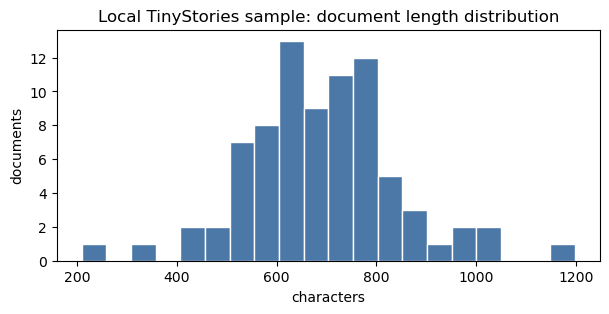

,original_preview,cleaned_preview,chars,caps_ratio,keep,reason
0,"Spot. Spot saw the shiny car and said, ""Wow, K...","Spot. Spot saw the shiny car and said, ""Wow, K...",348,0.052,True,kept
1,"Spot. Spot saw the shiny car and said, ""Wow, K...","Spot. Spot saw the shiny car and said, ""Wow, K...",348,0.052,False,too short / spam-like / duplicate
2,BUY NOW!!! LIMITED OFFER!!! EMAIL me at alice@...,BUY NOW!!! LIMITED OFFER!!! EMAIL me at [EMAIL...,65,0.750,False,too short / spam-like / duplicate
3,短文本。,短文本。,4,0.000,False,too short / spam-like / duplicate
4,This is a normal educational paragraph about n...,This is a normal educational paragraph about n...,81,0.014,True,kept


In [3]:
# 这格代码分为三步：
# 1) 展示几篇本地样本文档，展示预训练文本的具体样子。
# 2) 统计并绘制文档长度分布，说明训练数据有长有短。
# 3) 构造一个玩具清洗流水线，演示去重、过滤和隐私信息替换。

story_indices = [0, 1, 5]
rows = []
for i in story_indices:
    doc = stories[i]
    rows.append({
        "index": i,
        "chars": len(doc),
        "preview": doc[:260].replace("\n", " ") + ("..." if len(doc) > 260 else ""),
    })
display(pd.DataFrame(rows))

lengths = np.array([len(s) for s in stories])
print("文档长度统计:")
display(pd.Series(lengths).describe().to_frame("chars"))

plt.figure(figsize=(7, 3))
plt.hist(lengths, bins=20, color="#4C78A8", edgecolor="white")
plt.title("Local TinyStories sample: document length distribution")
plt.xlabel("characters")
plt.ylabel("documents")
plt.show()

# 一个玩具版数据清洗流程：真实系统会复杂很多。
dirty_docs = [
    stories[0],
    stories[0],  # 重复文档，用来演示去重。
    "BUY NOW!!! LIMITED OFFER!!! EMAIL me at alice@example.com and call 555-123-4567.",
    "短文本。",
    "This is a normal educational paragraph about neural networks and language models.",
]

email_re = re.compile(r"[\w.%-]+@[\w.-]+")
phone_re = re.compile(r"\b\d{3}[- ]\d{3}[- ]\d{4}\b")

def clean_doc(doc):
    doc = email_re.sub("[EMAIL]", doc)
    doc = phone_re.sub("[PHONE]", doc)
    doc = re.sub(r"\s+", " ", doc).strip()
    return doc

def caps_ratio(doc):
    letters = [ch for ch in doc if ch.isalpha()]
    if not letters:
        return 0.0
    return sum(ch.isupper() for ch in letters) / len(letters)

min_chars = 30
max_caps_ratio = 0.35
seen = set()
cleaned_rows = []
for doc in dirty_docs:
    cleaned = clean_doc(doc)
    keep = len(cleaned) >= min_chars and caps_ratio(cleaned) <= max_caps_ratio and cleaned not in seen
    cleaned_rows.append({
        "original_preview": doc[:70].replace("\n", " "),
        "cleaned_preview": cleaned[:90],
        "chars": len(cleaned),
        "caps_ratio": round(caps_ratio(cleaned), 3),
        "keep": keep,
        "reason": "kept" if keep else "too short / spam-like / duplicate",
    })
    if keep:
        seen.add(cleaned)

display(pd.DataFrame(cleaned_rows))


**输出怎么看**

- 第一张表显示了 3 篇样本文档的开头和字符数，其中最长示例有 1198 个字符。
- 长度统计表显示 80 篇样本平均约 690.6 个字符，最短 209，最长 1198；直方图展示长度分布。
- 清洗表里，重复文档、全大写广告和极短中文文本被过滤，邮箱被替换成 `[EMAIL]`。
- 这个输出说明：模型最终学到什么，很大程度上取决于训练前哪些文本被保留、哪些被删除、哪些敏感信息被替换。


## 3. Tokenization：模型看到的是 token 序列

这一格把若干字符串送进 GPT-2 tokenizer，并把每个 token 拆成表格：位置、token id、解码后的片段、UTF-8 字节和字符数。它直接回应讲义里的关键点：模型不是按人类直觉中的“词”或“字母”来读文本，而是读一串整数 token id。

输出来源：这里使用真实 GPT-2 tokenizer 的编码结果，但不调用模型生成回答；这是 tokenizer 机制演示。

可以改的地方：改 `texts` 列表，加入现场提出的词、中文、emoji、代码片段、长空格或标点串。观察三个问题：token 数是否变化、token 片段是否符合人的直觉、UTF-8 字节数和字符数为什么可能不同。


In [4]:
# 这格代码分为三步：
# 1) 定义 token_table，把字符串切成 token，并记录每个 token 的可读信息。
# 2) 准备一组容易体现差异的文本：大小写、空格、中文、英文单词和标点串。
# 3) 逐个文本显示 token 表，方便逐行比较。

def repr_token(token_id):
    piece = tokenizer.decode([int(token_id)])
    return repr(piece)

def token_table(text, max_rows=80):
    ids = tokenizer.encode(text, add_special_tokens=False)
    rows = []
    for pos, token_id in enumerate(ids[:max_rows]):
        piece = tokenizer.decode([token_id])
        rows.append({
            "pos": pos,
            "token_id": token_id,
            "decoded_piece": repr(piece),
            "utf8_bytes": list(piece.encode("utf-8", errors="replace")),
            "piece_chars": len(piece),
        })
    return pd.DataFrame(rows), ids

texts = [
    "hello world",
    "Hello world",
    "hello  world",
    "人工智能不是魔法，而是一套工程系统。",
    "strawberry",
    "." * 37,
]

for text in texts:
    print("=" * 90)
    print("输入:", repr(text))
    df, ids = token_table(text)
    print("token 数:", len(ids), "token ids:", ids)
    display(df)


输入: 'hello world'
token 数: 2 token ids: [31373, 995]


,pos,token_id,decoded_piece,utf8_bytes,piece_chars
0,0,31373,'hello',"[104, 101, 108, 108, 111]",5
1,1,995,' world',"[32, 119, 111, 114, 108, 100]",6


输入: 'Hello world'
token 数: 2 token ids: [15496, 995]


,pos,token_id,decoded_piece,utf8_bytes,piece_chars
0,0,15496,'Hello',"[72, 101, 108, 108, 111]",5
1,1,995,' world',"[32, 119, 111, 114, 108, 100]",6


输入: 'hello  world'
token 数: 3 token ids: [31373, 220, 995]


...

,pos,token_id,decoded_piece,utf8_bytes,piece_chars
0,0,21689,'人',"[228, 186, 186]",1
1,1,32432,'�',"[239, 191, 189]",1
2,2,98,'�',"[239, 191, 189]",1
3,3,162,'�',"[239, 191, 189]",1
4,4,247,'�',"[239, 191, 189]",1
5,5,118,'�',"[239, 191, 189]",1
6,6,47797,'�',"[239, 191, 189]",1
7,7,121,'�',"[239, 191, 189]",1
8,8,38834,'不',"[228, 184, 141]",1
9,9,42468,'是',"[230, 152, 175]",1


输入: 'strawberry'
token 数: 3 token ids: [301, 1831, 8396]


,pos,token_id,decoded_piece,utf8_bytes,piece_chars
0,0,301,'st',"[115, 116]",2
1,1,1831,'raw',"[114, 97, 119]",3
2,2,8396,'berry',"[98, 101, 114, 114, 121]",5


输入: '.....................................'
token 数: 2 token ids: [8864, 12359]


,pos,token_id,decoded_piece,utf8_bytes,piece_chars
0,0,8864,'................................',"[46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 4...",32
1,1,12359,'.....',"[46, 46, 46, 46, 46]",5


**输出怎么看**

- `hello world` 被切成两个 token：`hello` 和带前导空格的 ` world`。
- `Hello world` 的第一个 token id 不同，说明大小写会影响编码。
- `hello  world` 变成 3 个 token，中间多出的空格单独成 token。
- 后面的中文、emoji 和代码示例也会展示相同原则：token 边界不是人类自然词边界。
- 这个输出表达的含义是：模型后续所有概率、attention 和生成都发生在 token id 序列上。


### 3.1 同样输入在 Qwen tokenizer 中的 token

上一格展示的是 GPT-2 tokenizer。这里换成本地 `Qwen/Qwen2.5-0.5B-Instruct` 目录里的 tokenizer，用完全相同的 `texts` 做编码，并把 GPT-2 和 Qwen 的 token 数放在同一张表里比较。

输出来源：这里使用的是真实 Qwen tokenizer 的编码结果，但只做 tokenization，不调用 Qwen 模型生成回答。换句话说，这一格回答的是“同一段文本在 Qwen 词表里会变成哪些 token”，不是“Qwen 会如何回答”。

可以改的地方：直接改上一格的 `texts` 列表，这一格会自动复用同样输入。特别建议比较中文、连续标点、空格和英文大小写，因为不同 tokenizer 在这些输入上的差异很明显。


In [5]:
# 这格代码分为四步：
# 1) 确认本地 Qwen 指令模型目录存在；如果不存在，按需下载。
# 2) 只加载 Qwen tokenizer，不加载 Qwen 语言模型权重。
# 3) 对上一格相同的 texts 编码，并和 GPT-2 token 数做总览比较。
# 4) 展示每个输入在 Qwen tokenizer 下的 token id、原始 token 字符串和解码片段。

ensure_hf_snapshot(
    ASSISTANT_MODEL_REPO,
    ASSISTANT_MODEL_DIR,
    ASSISTANT_REQUIRED_FILES,
    ASSISTANT_ALLOW_PATTERNS,
    "Qwen 指令模型",
)

qwen_tokenizer = AutoTokenizer.from_pretrained(ASSISTANT_MODEL_DIR, local_files_only=True)


def qwen_token_table(text, max_rows=120):
    ids = qwen_tokenizer.encode(text, add_special_tokens=False)
    rows = []
    for pos, token_id in enumerate(ids[:max_rows]):
        raw_token = qwen_tokenizer.convert_ids_to_tokens(int(token_id))
        piece = qwen_tokenizer.decode([int(token_id)], skip_special_tokens=False)
        rows.append({
            "pos": pos,
            "token_id": int(token_id),
            "raw_token": repr(raw_token),
            "decoded_piece": repr(piece),
            "utf8_bytes": list(piece.encode("utf-8", errors="replace")),
            "piece_chars": len(piece),
        })
    return pd.DataFrame(rows), ids

comparison_rows = []
for text in texts:
    gpt2_ids = tokenizer.encode(text, add_special_tokens=False)
    qwen_df, qwen_ids = qwen_token_table(text)
    comparison_rows.append({
        "input": repr(text),
        "gpt2_token_count": len(gpt2_ids),
        "qwen_token_count": len(qwen_ids),
        "qwen_token_ids": qwen_ids,
    })

print("GPT-2 tokenizer 与 Qwen tokenizer 的 token 数比较：")
display(pd.DataFrame(comparison_rows))

for text in texts:
    print("=" * 90)
    print("输入:", repr(text))
    qwen_df, qwen_ids = qwen_token_table(text)
    print("Qwen token 数:", len(qwen_ids), "token ids:", qwen_ids)
    display(qwen_df)


GPT-2 tokenizer 与 Qwen tokenizer 的 token 数比较：


,input,gpt2_token_count,qwen_token_count,qwen_token_ids
0,'hello world',2,2,"[14990, 1879]"
1,'Hello world',2,2,"[9707, 1879]"
2,'hello world',3,3,"[14990, 220, 1879]"
3,'人工智能不是魔法，而是一套工程系统。',34,10,"[104455, 99520, 106083, 3837, 68536, 99639, 99..."
4,'strawberry',3,3,"[495, 672, 15357]"
5,'.....................................',2,2,"[16562, 18083]"


输入: 'hello world'
Qwen token 数: 2 token ids: [14990, 1879]


,pos,token_id,raw_token,decoded_piece,utf8_bytes,piece_chars
0,0,14990,'hello','hello',"[104, 101, 108, 108, 111]",5
1,1,1879,'Ġworld',' world',"[32, 119, 111, 114, 108, 100]",6


输入: 'Hello world'
Qwen token 数: 2 token ids: [9707, 1879]


...

,pos,token_id,raw_token,decoded_piece,utf8_bytes,piece_chars
0,0,104455,'äººå·¥æĻºèĥ½','人工智能',"[228, 186, 186, 229, 183, 165, 230, 153, 186, ...",4
1,1,99520,'ä¸įæĺ¯','不是',"[228, 184, 141, 230, 152, 175]",2
2,2,106083,'éŃĶæ³ķ','魔法',"[233, 173, 148, 230, 179, 149]",2
3,3,3837,'ï¼Į','，',"[239, 188, 140]",1
4,4,68536,'èĢĮ','而',"[232, 128, 140]",1
5,5,99639,'æĺ¯ä¸Ģ','是一',"[230, 152, 175, 228, 184, 128]",2
6,6,99619,'å¥Ĺ','套',"[229, 165, 151]",1
7,7,99655,'å·¥ç¨ĭ','工程',"[229, 183, 165, 231, 168, 139]",2
8,8,72448,'ç³»ç»Ł','系统',"[231, 179, 187, 231, 187, 159]",2
9,9,1773,'ãĢĤ','。',"[227, 128, 130]",1


输入: 'strawberry'
Qwen token 数: 3 token ids: [495, 672, 15357]


,pos,token_id,raw_token,decoded_piece,utf8_bytes,piece_chars
0,0,495,'str','str',"[115, 116, 114]",3
1,1,672,'aw','aw',"[97, 119]",2
2,2,15357,'berry','berry',"[98, 101, 114, 114, 121]",5


输入: '.....................................'
Qwen token 数: 2 token ids: [16562, 18083]


,pos,token_id,raw_token,decoded_piece,utf8_bytes,piece_chars
0,0,16562,'................................','................................',"[46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 46, 4...",32
1,1,18083,'.....','.....',"[46, 46, 46, 46, 46]",5


**输出怎么看**

- 总览表把同一输入在 GPT-2 和 Qwen tokenizer 下的 token 数放在一起。
- 英文短句结果相近：`hello world` 和 `Hello world` 都是 2 个 token，双空格版本都是 3 个 token。
- 中文句子差异很大：GPT-2 需要 34 个 token，Qwen 只需要 10 个 token，并且能解码出 `人工智能`、`不是`、`魔法`、`工程`、`系统` 这类更自然的中文片段。
- `strawberry` 两者都是 3 个 token，但 GPT-2 是 `st/raw/berry`，Qwen 是 `str/aw/berry`。
- 37 个连续点号两者都是 2 个 token，Qwen 切成 32 个点和 5 个点。
- `raw_token` 是 Qwen 词表里的原始符号，可能带有 `Ġ` 这样的空格标记或字节级显示；`decoded_piece` 才是单个 token 解码回来的可读文本。


## 4. BPE 直觉：常见相邻片段会被压缩成新符号

真实 GPT tokenizer 的字节级 BPE 规则很多，不适合在这里逐条展开。这里用一个玩具语料实现 BPE 的核心思想：把单词先拆成字符，再反复寻找最常见的相邻符号对，把它合并成一个新符号。

输出来源：这一节没有调用预训练模型；它是手写 toy BPE 算法，用来解释 tokenizer 的训练直觉。

这格代码和上一节配合起来看：tokenizer 不是人类词典，也不是简单按空格切词，而是从语料统计中学出来的一套压缩规则。语料里经常一起出现的片段更可能被合并，少见片段就会保留得更碎。

可以改的地方：改 `toy_corpus` 会改变最终学到的合并规则；改 `num_merges` 会改变压缩程度。可以先猜最先被合并的 pair，再运行代码看统计结果。


In [6]:
# 这格代码分为四步：
# 1) 把玩具语料按单词计数，并把每个单词拆成字符序列。
# 2) 统计所有相邻符号对的出现频率。
# 3) 每轮选择最常见 pair 合并，记录合并前后的符号总数。
# 4) 打印最终符号表示，展示 token 片段如何形成。

toy_corpus = "low lower lowest low lower newer newer wider wide"
num_merges = 8

word_counts = Counter(toy_corpus.split())
vocab = {tuple(list(word) + ["</w>"]): count for word, count in word_counts.items()}

def get_pair_stats(vocab):
    stats = Counter()
    for symbols, count in vocab.items():
        for pair in zip(symbols, symbols[1:]):
            stats[pair] += count
    return stats

def merge_pair(pair, vocab):
    merged_vocab = {}
    bigram = " ".join(pair)
    replacement = "".join(pair)
    pattern = re.compile(r"(?<!\S)" + re.escape(bigram) + r"(?!\S)")
    for symbols, count in vocab.items():
        text = " ".join(symbols)
        merged = tuple(pattern.sub(replacement, text).split())
        merged_vocab[merged] = count
    return merged_vocab

history = []
current_vocab = vocab
for step in range(1, num_merges + 1):
    stats = get_pair_stats(current_vocab)
    if not stats:
        break
    best_pair, freq = stats.most_common(1)[0]
    before_len = sum(len(symbols) * count for symbols, count in current_vocab.items())
    current_vocab = merge_pair(best_pair, current_vocab)
    after_len = sum(len(symbols) * count for symbols, count in current_vocab.items())
    history.append({
        "merge_step": step,
        "merged_pair": best_pair,
        "frequency": freq,
        "total_symbols_before": before_len,
        "total_symbols_after": after_len,
    })

display(pd.DataFrame(history))
print("最终玩具词表表示:")
for symbols, count in current_vocab.items():
    print(f"{count:2d} x", symbols)


,merge_step,merged_pair,frequency,total_symbols_before,total_symbols_after
0,1,"(l, o)",5,50,45
1,2,"(lo, w)",5,45,40
2,3,"(e, r)",5,40,35
3,4,"(er, </w>)",5,35,30
4,5,"(low, </w>)",2,30,28
5,6,"(low, er</w>)",2,28,26
6,7,"(n, e)",2,26,24
7,8,"(ne, w)",2,24,22


最终玩具词表表示:
 2 x ('low</w>',)
 2 x ('lower</w>',)
 1 x ('low', 'e', 's', 't', '</w>')
 2 x ('new', 'er</w>')
 1 x ('w', 'i', 'd', 'er</w>')
 1 x ('w', 'i', 'd', 'e', '</w>')


**输出怎么看**

- 合并历史表显示最早被合并的是 `(l, o)`、`(lo, w)`、`(e, r)`、`(er, </w>)`，因为它们在玩具语料里最常见。
- 总符号数从 50 降到 22，说明 BPE 本质上是在用更大的词表换取更短的序列。
- 最终词表里 `low</w>`、`lower</w>` 和 `new er</w>` 等片段展示了常见词会被压成更少 token，少见词仍然比较碎。


## 5. 最小预训练循环：预测下一个字符

这一格用 PyTorch 训练一个极小的 bigram 字符级语言模型。它不是 Transformer，也没有上下文窗口，只根据“当前字符”预测“下一个字符”。这个模型非常弱，但它保留了预训练最核心的形式：从数据中取相邻位置，计算下一个符号的交叉熵损失，然后用反向传播调整参数。

输出来源：这是本 Notebook 现场训练出来的玩具 bigram 模型，不是预训练大模型，也不是 Qwen/tiny GPT-2 输出。

这一节的重点不是模型效果，而是训练目标。训练前采样通常很乱；训练后采样会稍微更像训练文本，因为模型已经学到一些字符转移统计，例如空格后常出现字母，某些字母组合更常见。loss 曲线下降则说明模型越来越擅长预测训练数据里的下一个字符。

可以改的地方：改 `max_steps` 会影响训练时间和 loss 下降程度；改 `batch_size` 会影响每步估计的稳定性；改 `train_text = raw_text[:20000]` 的切片大小，会改变训练样本数量。


训练前采样:
 W,ttI qkdFfgfH'pcxlcF>
 zVfxnTtNTNNg.z<.|x"viOffvu?ValBeWF>'WYwVR iGppBqAB,EHsVO,>hkucNc,.|BYHWkwtzwttiPuyP!ocN.lgB WzhMY<?Dfy?n
zrE>hRY",NLL>'BYYxMyD>YwSwgnzw?

训练后采样:
 whe o t Itofovene thet ay, st pponthe ay. baledo liscana d to le,, as ne Sho Buey. s s he wandas I thomo le I andaghis to waOnd g.
<|>
Ond ad and anoue Tond Male re llasts ind he bung thag wa. y ethe bed d Buckeyoncove wa ce Day, pplut plal


/var/folders/kt/2x6n8zq16xv877ny91yyljth0000gn/T/ipykernel_63244/4209959074.py:56: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1779112954888/work/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  losses.append(float(loss))


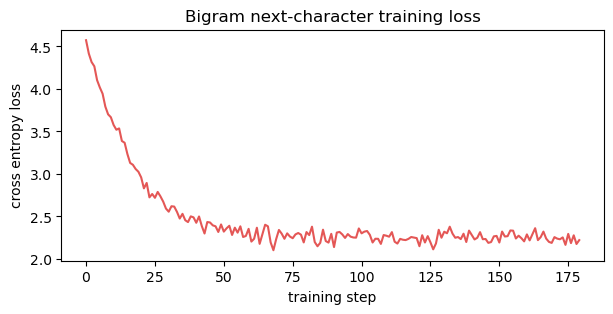

In [7]:
# 这格代码分为五步：
# 1) 从本地文本中取一小段训练字符，并建立字符到整数的词表。
# 2) 定义最小 bigram 模型：当前字符 id 直接查表得到下一个字符 logits。
# 3) 先训练前采样，展示随机参数下的输出。
# 4) 用交叉熵和 AdamW 做若干步训练。
# 5) 训练后再次采样并画 loss 曲线。

train_text = raw_text[:20000]
chars = sorted(set(train_text))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
data = torch.tensor([stoi[ch] for ch in train_text], dtype=torch.long)
vocab_size_chars = len(chars)

class BigramLanguageModel(torch.nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.table = torch.nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.table(idx)
        loss = None
        if targets is not None:
            loss = torch.nn.functional.cross_entropy(logits, targets)
        return logits, loss

    @torch.no_grad()
    def generate(self, start_id, max_new_tokens=120, temperature=1.0):
        idx = torch.tensor([start_id], dtype=torch.long)
        out = [start_id]
        for _ in range(max_new_tokens):
            logits, _ = self(idx[-1:])
            probs = torch.softmax(logits[-1] / temperature, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
            out.append(next_id)
            idx = torch.cat([idx, torch.tensor([next_id])])
        return "".join(itos[i] for i in out)

bigram = BigramLanguageModel(vocab_size_chars)
optimizer = torch.optim.AdamW(bigram.parameters(), lr=0.08)
max_steps = 180
batch_size = 512
losses = []

print("训练前采样:")
print(bigram.generate(stoi[" "], max_new_tokens=160, temperature=0.9))

for step in range(max_steps):
    ix = torch.randint(0, len(data) - 1, (batch_size,))
    x = data[ix]
    y = data[ix + 1]
    _, loss = bigram(x, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(float(loss))

print("\n训练后采样:")
print(bigram.generate(stoi[" "], max_new_tokens=240, temperature=0.8))

plt.figure(figsize=(7, 3))
plt.plot(losses, color="#E45756")
plt.title("Bigram next-character training loss")
plt.xlabel("training step")
plt.ylabel("cross entropy loss")
plt.show()


**输出怎么看**

- 训练前采样几乎是随机字符。
- 训练后采样出现了更多类似英文的局部片段，例如 `the`、`and`、空格和短词组合，但整体仍然不通顺。
- loss 曲线展示训练过程确实在优化 next-character prediction。
- 运行中出现的 PyTorch warning 来自把带梯度的 loss 转成 Python float，和语言模型原理无关；可以把 `loss.detach()` 加上消除警告。


## 6. 下一个 token 概率：一次前向传播输出整个词表的分布

这一格给 Qwen 一个 chat prompt，取 assistant 即将开始回答时最后一个位置的 logits，并用 softmax 转成概率，显示概率最高的若干个下一个 token。它展示了语言模型最核心的接口：输入上下文 token，输出“下一个 token 是词表中每个 token 的概率”。

输出来源：这里是真实 Qwen2.5-0.5B-Instruct 的一次前向传播输出；没有手写答案，也不是 tiny GPT-2。

重点是：模型并不是一次性生成完整回答。它每一步只做“下一个 token 预测”，然后系统选择一个 token 接到后面，再重复这个过程。相比 tiny GPT-2，Qwen 的 top token 会更贴合问题，因此更适合课堂上现场换 prompt 观察。

可以改的地方：改 `next_token_messages` 中的用户问题，看 Qwen 在回答开头更倾向于输出什么；改 `top_k` 看更多或更少候选；观察概率是否集中。


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen chat template 输入：
<|im_start|>system
你是神经网络课程的简洁助教。<|im_end|>
<|im_start|>user
请用一句话解释 tokenization。<|im_end|>
<|im_start|>assistant



,rank,token_id,decoded_token,raw_token,probability
0,1,3323,'Token','Token',0.474365
1,2,5839,'token','token',0.393311
2,3,44063,'将','å°Ĩ',0.053223
3,4,18493,'在','åľ¨',0.032288
4,5,20412,'是','æĺ¯',0.003098
5,6,37434,'Tokenizer','Tokenizer',0.002865
6,7,37029,'使用','ä½¿çĶ¨',0.001880
7,8,3950,' token','Ġtoken',0.001780
8,9,67338,'通过','éĢļè¿ĩ',0.001607
9,10,13274,'(token','(token',0.001595


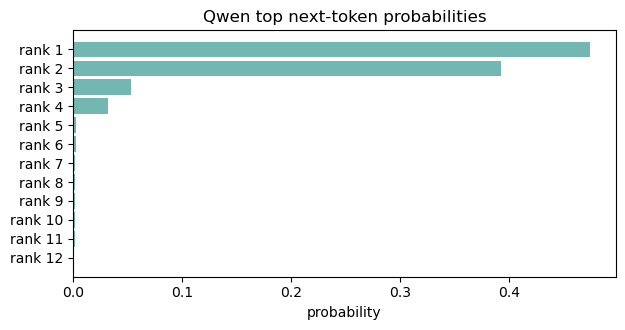

In [8]:
# 这格代码分为三步：
# 1) 用 Qwen chat template 把 messages 编码成模型输入。
# 2) 取最后一个位置的 logits，用 softmax 转成概率。
# 3) 取概率最高的 top-k token，做成表格和柱状图。


def qwen_next_token_distribution(messages, top_k=12):
    qwen_tok, qwen_model, qwen_device = load_assistant_model()
    encoded = qwen_tok.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True,
    ).to(qwen_device)
    with torch.no_grad():
        outputs = qwen_model(**encoded)
    logits = outputs.logits[0, -1]
    probs = torch.softmax(logits, dim=-1)
    values, indices = torch.topk(probs, k=top_k)
    df = pd.DataFrame({
        "rank": np.arange(1, top_k + 1),
        "token_id": indices.detach().cpu().numpy(),
        "decoded_token": [repr(qwen_tok.decode([int(i)])) for i in indices.detach().cpu().numpy()],
        "raw_token": [repr(qwen_tok.convert_ids_to_tokens(int(i))) for i in indices.detach().cpu().numpy()],
        "probability": values.detach().cpu().numpy(),
    })
    prompt_text = qwen_tok.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    return df, prompt_text

next_token_messages = [
    {"role": "system", "content": "你是神经网络课程的简洁助教。"},
    {"role": "user", "content": "请用一句话解释 tokenization。"},
]
top_k = 12
df_next, rendered_prompt = qwen_next_token_distribution(next_token_messages, top_k=top_k)
print("Qwen chat template 输入：")
print(rendered_prompt)
display(df_next)

plt.figure(figsize=(7, 3.2))
plt.barh([f"rank {r}" for r in df_next["rank"]][::-1], df_next["probability"][::-1], color="#72B7B2")
plt.title("Qwen top next-token probabilities")
plt.xlabel("probability")
plt.show()


**输出怎么看**

- 表格列出的是 Qwen 在 assistant 即将开始回答时最可能输出的下一个 token。
- 对于“请用一句话解释 tokenization”这个问题，最高候选是 `Token`，概率约 0.474；第二是 `token`，概率约 0.393；后面还有 `将`、`在`、`是` 等中文回答开头。
- 相比 tiny GPT-2 的平坦无关分布，Qwen 在第一步已经明显围绕问题组织回答。
- `raw_token` 是 Qwen 词表里的原始符号，`decoded_token` 是解码后的可读文本。


## 7. 自回归生成：把选出的 token 接回输入

第 6 节只看了一次前向传播：给定上下文，Qwen 输出“下一个 token”的概率分布。真正说出一句话时，系统会先从这个分布里选一个 token，把它接到原来的上下文后面；下一轮再把“原上下文 + 已生成 token”整体送回模型，继续预测下一个 token。这个过程不断循环，最后才拼出一句完整回答。

输出来源：这一节的 token、概率和最终文本都来自真实 Qwen2.5-0.5B-Instruct。代码里手写的是外层循环和展示表格，不是手写模型输出。

可以改的地方：改 `loop_messages` 里的用户问题，观察逐 token 生成路径怎样改变；改 `max_steps` 控制最多生成多少个 token；改 `top_k` 看每一步更多候选。

### 7.1 手写循环：一次只接一个 token

下面这格故意不用 `model.generate()`，而是把自回归生成过程拆开写出来：前向传播、取下一个 token 分布、选中一个 token、拼回输入、进入下一轮。这样学生能直接看到“一句话”并不是一次吐出来的，而是一个 token 一个 token 接出来的。


In [9]:
# 这格代码分为四步：
# 1) 把 chat messages 编码成 Qwen 的输入 token。
# 2) 每一轮只做一次前向传播，得到当前位置的下一个 token 概率。
# 3) 用贪心策略选择概率最高的 token，并把它接回 input_ids。
# 4) 打印每轮候选和已经接出来的文本，观察输入序列如何逐步变长。

def manual_qwen_autoregressive_loop(messages, max_steps=22, top_k=3):
    qwen_tok, qwen_model, qwen_device = load_assistant_model()
    input_ids = encode_assistant_chat(messages)["input_ids"].clone()
    prompt_len = input_ids.shape[-1]
    rows = []

    with torch.no_grad():
        for step in range(1, max_steps + 1):
            input_len_before = input_ids.shape[-1]
            outputs = qwen_model(input_ids=input_ids)
            probs = torch.softmax(outputs.logits[0, -1], dim=-1)
            values, ids = torch.topk(probs, k=top_k)
            chosen_id = int(ids[0])
            chosen_piece = qwen_tok.decode([chosen_id], skip_special_tokens=False)

            input_ids = torch.cat([
                input_ids,
                torch.tensor([[chosen_id]], device=qwen_device),
            ], dim=-1)
            generated_ids = input_ids[0, prompt_len:].detach().cpu().tolist()
            generated_so_far = qwen_tok.decode(generated_ids, skip_special_tokens=True)
            next_input_tail = qwen_tok.decode(
                input_ids[0, max(0, input_ids.shape[-1] - 20):].detach().cpu().tolist(),
                skip_special_tokens=False,
            )

            row = {
                "step": step,
                "输入 token 数(本轮前)": int(input_len_before),
                "chosen": repr(chosen_piece),
                "chosen_id": chosen_id,
                "generated_so_far": generated_so_far,
                "下一轮输入末尾": next_input_tail,
            }
            for rank, (token_id, prob) in enumerate(zip(ids.detach().cpu().tolist(), values.detach().cpu().tolist()), start=1):
                row[f"top{rank}"] = repr(qwen_tok.decode([int(token_id)], skip_special_tokens=False))
                row[f"top{rank}_prob"] = float(prob)
            rows.append(row)

            if chosen_id == qwen_tok.eos_token_id:
                break
            if step >= 4 and generated_so_far.strip().endswith(("。", "！", "？", ".", "!", "?")):
                break

    return pd.DataFrame(rows), generated_so_far.strip()


loop_messages = [
    {"role": "system", "content": "你是神经网络课程的简洁助教。"},
    {"role": "user", "content": "请用一句话说明语言模型怎样逐步生成文本。"},
]
print("初始 Qwen chat template 输入：")
print(render_assistant_chat(loop_messages))
trace_df, loop_answer = manual_qwen_autoregressive_loop(loop_messages, max_steps=22, top_k=3)
display(trace_df)
print("最终接出来的一句话：")
print(loop_answer)


初始 Qwen chat template 输入：
<|im_start|>system
你是神经网络课程的简洁助教。<|im_end|>
<|im_start|>user
请用一句话说明语言模型怎样逐步生成文本。<|im_end|>
<|im_start|>assistant



,step,输入 token 数(本轮前),chosen,chosen_id,generated_so_far,下一轮输入末尾,top1,top1_prob,top2,top2_prob,top3,top3_prob
0,1,33,'语言',102064,语言,<|im_start|>user\n请用一句话说明语言模型怎样逐步生成文本。<|im_end...,'语言',0.841309,'通过',0.029236,'当',0.020737
1,2,34,'模型',104949,语言模型,user\n请用一句话说明语言模型怎样逐步生成文本。<|im_end|>\n<|im_sta...,'模型',0.999512,'生成',0.000380,'模',0.000045
2,3,35,'通过',67338,语言模型通过,\n请用一句话说明语言模型怎样逐步生成文本。<|im_end|>\n<|im_start|>...,'通过',0.692383,'使用',0.069641,'在',0.025620
3,4,36,'学习',100134,语言模型通过学习,请用一句话说明语言模型怎样逐步生成文本。<|im_end|>\n<|im_start|>as...,'学习',0.224243,'训练',0.174683,'不断',0.069458
4,5,37,'大量的',101514,语言模型通过学习大量的,用一句话说明语言模型怎样逐步生成文本。<|im_end|>\n<|im_start|>ass...,'大量的',0.506836,'大量',0.312256,'和',0.090881
5,6,38,'文本',108704,语言模型通过学习大量的文本,一句话说明语言模型怎样逐步生成文本。<|im_end|>\n<|im_start|>assi...,'文本',0.629883,'语言',0.092163,'上下',0.057648
6,7,39,'数据',20074,语言模型通过学习大量的文本数据,说明语言模型怎样逐步生成文本。<|im_end|>\n<|im_start|>assista...,'数据',0.896484,'对',0.051361,'输入',0.010597
7,8,40,'，',3837,语言模型通过学习大量的文本数据，,语言模型怎样逐步生成文本。<|im_end|>\n<|im_start|>assistant...,'，',0.658203,'来',0.121765,'和',0.075012
8,9,41,'逐步',104137,语言模型通过学习大量的文本数据，逐步,模型怎样逐步生成文本。<|im_end|>\n<|im_start|>assistant\n...,'逐步',0.114136,'训练',0.086121,'逐渐',0.080933
9,10,42,'训练',104034,语言模型通过学习大量的文本数据，逐步训练,怎样逐步生成文本。<|im_end|>\n<|im_start|>assistant\n语言...,'训练',0.388428,'构建',0.078918,'积累',0.066467


最终接出来的一句话：
语言模型通过学习大量的文本数据，逐步训练出其对语言的理解和生成能力。


**输出怎么看**

- 表格每一行就是一次 Qwen 前向传播：本轮输入进去一整段上下文，模型只预测下一个 token。
- 第 1 步本轮前输入长度是 33 个 token，Qwen 选择 `语言`；第 2 步输入长度变成 34，说明 `语言` 已经被接回输入。
- 这个长度每轮增加 1，一直增加到第 19 步的 51 个 token；最后一轮选择 `。`，把句子收住。
- `top1/top2/top3` 是模型当时认为最可能的候选，`chosen` 是这次用贪心策略实际接上的 token；例如第 1 步 `语言` 的概率约 0.841。
- `generated_so_far` 从 `语言` 逐步变成“语言模型通过学习大量的文本数据，逐步训练出其对语言的理解和生成能力。”，可以直接看到一句话是逐 token 接出来的。
- `下一轮输入末尾` 显示的是更新后的完整上下文尾部，强调下一轮不是只看刚刚那个 token，而是看“原问题 + 已生成内容”的整体。


### 7.2 交给 Transformers 自动循环并流式输出

上面一格把循环手写出来，是为了看清楚机制。实际使用模型时，通常不会自己写每一步 forward 和拼接，而是交给 `generate()`、pipeline 或服务端生成接口。下面用 Transformers 的 `TextIteratorStreamer` 做流式输出：后台的 `generate()` 自动完成同样的自回归循环，前台一边收到新文本片段一边打印出来。

输出来源：这里仍然是真实 Qwen2.5-0.5B-Instruct 的生成文本。我们没有手写答案，只是使用 Transformers 封装好的生成和流式解码工具。


In [10]:
# 这格代码分为三步：
# 1) 准备 Qwen 输入，并创建 TextIteratorStreamer。
# 2) 在后台线程中调用 model.generate()，让 Transformers 自动完成逐 token 循环。
# 3) 前台不断读取 streamer，模拟课堂上看到模型一点点吐出回答。

from threading import Thread
from transformers import TextIteratorStreamer

stream_messages = [
    {"role": "system", "content": "你是神经网络课程的简洁助教。回答必须基于自回归 Transformer：每次预测一个 token，再把它接回上下文继续预测。不要提 RNN、LSTM 或 GRU。"},
    {"role": "user", "content": "请用一句话解释 Qwen 为什么能流式输出回答。"},
]
qwen_tok, qwen_model, _ = load_assistant_model()
stream_inputs = encode_assistant_chat(stream_messages)
streamer = TextIteratorStreamer(qwen_tok, skip_prompt=True, skip_special_tokens=True)
generation_kwargs = {k: v for k, v in stream_inputs.items()}
generation_kwargs.update({
    "streamer": streamer,
    "max_new_tokens": 60,
    "do_sample": False,
    "pad_token_id": qwen_tok.eos_token_id,
})

thread = Thread(target=qwen_model.generate, kwargs=generation_kwargs)
print("Qwen 流式输出：", end="")
thread.start()
chunks = []
for chunk in streamer:
    print(chunk, end="", flush=True)
    chunks.append(chunk)
thread.join()

stream_answer = "".join(chunks).strip()
print("\n\n完整回答：")
print(stream_answer)


Qwen 流式输出：Qwen通过使用自回归Transformer模型，能够实时生成并回应用户的问题。

完整回答：
Qwen通过使用自回归Transformer模型，能够实时生成并回应用户的问题。


**输出怎么看**

- `Qwen 流式输出` 先后打印出 `Qwen通过`、`使用`、`自`、`回归`、`Transformer模型` 等片段，最终拼成一句完整回答。
- `TextIteratorStreamer` 输出的是解码后的文本片段，不一定和底层 token 一一对应；课堂上看到的是“文本块逐步出现”的效果。
- 这格没有手写 token 选择循环；循环、拼接上下文、停止条件和解码都由 Transformers 的 `generate()` 处理。
- 底层机制仍然和 7.1 一样：模型每次预测下一个 token，系统把它接回上下文，再继续下一轮。
- `完整回答` 是把所有流式片段拼接后的最终文本：“Qwen通过使用自回归Transformer模型，能够实时生成并回应用户的问题。”


## 8. 推理采样：temperature 控制随机性

前一节已经把“下一个 token 概率”手写循环起来。这一节继续使用同一个生成机制，但把重点放在 temperature 如何改变采样分布，进而改变 Qwen 生成文本的稳定性和多样性。`temperature` 会改变概率分布的尖锐程度：低 temperature 更保守，更容易给出稳妥回答；高 temperature 更随机，更容易出现发散、细节变化或不稳定输出。

输出来源：这里调用真实 Qwen2.5-0.5B-Instruct 生成文本；不是 tiny GPT-2，也不是手写模板。

可以先固定用户问题，然后比较同一个 temperature 下不同 `seed` 的输出，再比较不同 temperature 的输出。这样可以看到两个事实：第一，生成包含采样过程，不是固定答案；第二，采样策略影响最终文本的风格和稳定性。

可以改的地方：改 `sampling_user_prompt`，现场让 Qwen 写解释、类比、小故事或课堂例子；改 `temperatures` 观察保守和发散的差别。


In [11]:
# 这格代码分为三步：
# 1) 准备一个可读性较强的中文生成任务。
# 2) 用不同 temperature 和 seed 调用 Qwen 生成文本。
# 3) 打印结果，比较采样参数如何影响输出随机性和风格。

sampling_user_prompt = "请用两句话写一个小机器人在课堂上学习 tokenization 的故事。"
sampling_messages = [
    {"role": "system", "content": "你是一个中文写作助手，回答要自然。"},
    {"role": "user", "content": sampling_user_prompt},
]
temperatures = [0.2, 0.8, 1.2]
for temp in temperatures:
    print("=" * 90)
    print(f"temperature = {temp}")
    for seed in [1, 2]:
        answer = chat_generate(
            sampling_messages,
            max_new_tokens=120,
            temperature=temp,
            top_p=0.9,
            seed=seed,
        )
        print(f"seed {seed}:", answer)


temperature = 0.2
seed 1: 小机器人在课堂上尝试使用tokenization进行文本分析，发现了一些有趣的数据和信息。
seed 2: 小机器人在课堂上开始学习tokenization，通过反复练习和实践，逐渐掌握了这个关键的文本处理技能。
temperature = 0.8
seed 1: 小机器人开始时只会读单词，但随着时间的推移，它学会了如何将每个单词拆分成单独的字符（token）。通过不断的学习和实践，小机器人逐渐掌握了这个技能，最终能够理解复杂的句子，并准确地进行分词处理。这个过程不仅锻炼了机器人的语言能力，也展示了它们强大的学习能力和适应新知识的能力。
seed 2: 小机器人小A被分配到一个虚拟教室里进行英语口语练习。老师要求她使用tokenization来识别单词的词性，并将其与相应的音标匹配起来。

小A开始尝试各种语法结构和词汇，但随着时间的推移，她的理解和应用能力有了显著提高。最终，在一次模拟考试中，小A以惊人的成绩取得了第一名的好成绩，成为了全班最聪明的学生之一。
temperature = 1.2
seed 1: 小机器人开始时只会读单词，但不久后学会了如何根据语义分解短语。
seed 2: 小机器人小Q从课桌前一跃而起，开始熟练地执行了token化功能，将一系列文字变成一个单词。孩子们的笑声洋溢在整个教室里。


**输出怎么看**

- 低 temperature 下，Qwen 的故事通常短、稳、围绕“学习 tokenization”本身。
- 中等 temperature 会加入更多课堂情节和解释。
- 高 temperature 更可能出现跳跃、拟人化或细节不稳。
- 比较同一个 temperature 下两个 seed，也能看到相同任务并不只有唯一答案。
- 这里的关键不是哪一版最好，而是看到采样参数如何改变真实模型输出的多样性。


## 9. Transformer 结构：Qwen 的参数、层和张量形状

这一格把本地 Qwen 指令模型当作一个可检查的 PyTorch 模块来观察。它会显示模型配置，例如层数、head 数、hidden size、上下文长度和词表大小；再用一个 chat prompt 做前向传播，展示 `input_ids`、hidden state 和 logits 的形状。

输出来源：这里检查的是真实 Qwen2.5-0.5B-Instruct 的参数和前向传播形状；这是结构演示，不是手写说明，也不是 tiny GPT-2。

可以改的地方：改 `shape_messages` 增减输入 token 数，观察第二维如何变化；改表格里的字段，查看更多 Qwen config。为了避免输出过长，这一格不打印完整模型对象，而是展示关键模块和参数分组。


In [12]:
# 这格代码分为四步：
# 1) 加载本地 Qwen tokenizer 和模型，读取配置并整理成表。
# 2) 打印关键模块名称，展示 Qwen Transformer 的组成。
# 3) 用一段 chat prompt 做前向传播，查看关键张量形状。
# 4) 按参数名称分组，粗略查看参数分布。

qwen_tok, qwen_model, qwen_device = load_assistant_model()
qcfg = qwen_model.config
qwen_num_params = sum(p.numel() for p in qwen_model.parameters())
qwen_summary = {
    "model_type": qcfg.model_type,
    "num_hidden_layers": getattr(qcfg, "num_hidden_layers", None),
    "num_attention_heads": getattr(qcfg, "num_attention_heads", None),
    "num_key_value_heads": getattr(qcfg, "num_key_value_heads", None),
    "hidden_size": getattr(qcfg, "hidden_size", None),
    "intermediate_size": getattr(qcfg, "intermediate_size", None),
    "max_position_embeddings": getattr(qcfg, "max_position_embeddings", None),
    "vocab_size": qcfg.vocab_size,
    "num_parameters": qwen_num_params,
}
display(pd.DataFrame([qwen_summary]).T.rename(columns={0: "value"}))

print("Qwen 模型类型:", type(qwen_model).__name__)
print("主体模块:", type(qwen_model.model).__name__)
print("词嵌入模块:", qwen_model.model.embed_tokens)
print("第一层 Transformer block:")
print(qwen_model.model.layers[0])
print("输出头:", qwen_model.lm_head)

shape_messages = [
    {"role": "system", "content": "你是神经网络课程的简洁助教。"},
    {"role": "user", "content": "用一句话解释语言模型如何学习。"},
]
shape_inputs = qwen_tok.apply_chat_template(
    shape_messages,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True,
).to(qwen_device)
with torch.no_grad():
    qwen_outputs = qwen_model(**shape_inputs, output_hidden_states=True)

print("\nchat template token 数:", int(shape_inputs["input_ids"].shape[-1]))
print("input_ids shape:", tuple(shape_inputs["input_ids"].shape))
print("最后一层 hidden state shape:", tuple(qwen_outputs.hidden_states[-1].shape))
print("logits shape:", tuple(qwen_outputs.logits.shape), "= batch x seq_len x vocab_size")

param_rows = []
for name, p in qwen_model.named_parameters():
    group = name.split(".")[0]
    if group == "model" and len(name.split(".")) > 1:
        group = "model." + name.split(".")[1]
    param_rows.append({"group": group, "params": p.numel()})
display(pd.DataFrame(param_rows).groupby("group", as_index=False).sum().sort_values("params", ascending=False))


,value
model_type,qwen2
num_hidden_layers,24
num_attention_heads,14
num_key_value_heads,2
hidden_size,896
intermediate_size,4864
max_position_embeddings,32768
vocab_size,151936
num_parameters,494032768


Qwen 模型类型: Qwen2ForCausalLM
主体模块: Qwen2Model
词嵌入模块: Embedding(151936, 896)
第一层 Transformer block:
Qwen2DecoderLayer(
  (self_attn): Qwen2Attention(
    (q_proj): Linear(in_features=896, out_features=896, bias=True)
    (k_proj): Linear(in_features=896, out_features=128, bias=True)
    (v_proj): Linear(in_features=896, out_features=128, bias=True)
    (o_proj): Linear(in_features=896, out_features=896, bias=False)
  )
  (mlp): Qwen2MLP(
    (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
    (up_proj): Linear(in_features=896, out_features=4864, bias=False)
    (down_proj): Linear(in_features=4864, out_features=896, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
  (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
)
输出头: Linear(in_features=896, out_features=151936, bias=False)

chat template token 数: 30
input_ids shape: (1, 30)
最后一层 hidden state shape: (1, 30, 896)
logits shape: (1, 30, 151936) = batch x se

,group,params
1,model.layers,357897216
0,model.embed_tokens,136134656
2,model.norm,896


**输出怎么看**

- 配置表展示的是本地 Qwen2.5-0.5B-Instruct 的真实尺寸：24 层、14 个 attention heads、2 个 key/value heads、hidden size 896、上下文长度 32768、词表大小 151936，总参数量 494,032,768。
- 关键模块输出里可以看到 embedding、第一层 self-attention / MLP / RMSNorm，以及最终 `lm_head`。
- 示例 chat prompt 被序列化成 30 个 token，所以 hidden state 形状是 `(1, 30, 896)`，logits 形状是 `(1, 30, 151936)`。
- 这说明更强的 Qwen 和 tiny GPT-2 在接口上仍然一致：每个位置都输出一个词表分布，只是规模和能力差别很大。


## 10. Attention 可视化：当前位置如何看前文

这一格打开模型的 attention 输出，取某一层某一个 head，画成热力图。横轴表示“被看的 token”，纵轴表示“正在计算的 token”。对 GPT 这类自回归模型来说，一个位置只能看自己和左边，不能看未来 token，所以图中未来方向会被 causal mask 屏蔽。

输出来源：这里展示的是真实预训练 tiny GPT-2 的 attention 权重；它是机制演示，不要把这些权重解释成可靠语义理解。

需要注意：这个 tiny 模型的 attention 不一定有清楚语义，不要过度解释“它在理解猫坐在垫子上”。真正要看的有两点：第一，attention 是一个 token 到 token 的权重矩阵；第二，自回归模型的注意力结构天然体现从左到右生成。

可以改的地方：改 `attention_text` 看不同 token 序列；改 `layer_idx` 和 `head_idx` 看不同层不同头。输出表格和热力图是同一个矩阵的两种表示。


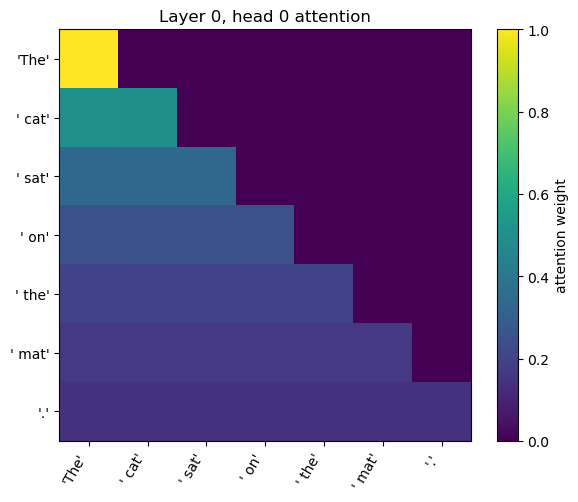

,'The',' cat',' sat',' on',' the',' mat','.'
'The',1.000,0.000,0.000,0.000,0.000,0.000,0.000
' cat',0.500,0.500,0.000,0.000,0.000,0.000,0.000
' sat',0.333,0.333,0.333,0.000,0.000,0.000,0.000
' on',0.250,0.250,0.250,0.250,0.000,0.000,0.000
' the',0.200,0.200,0.200,0.200,0.200,0.000,0.000
' mat',0.167,0.167,0.167,0.167,0.167,0.167,0.000
'.',0.143,0.143,0.143,0.143,0.143,0.143,0.143


In [13]:
# 这格代码分为四步：
# 1) 把一段文本编码成 token。
# 2) 前向传播时要求模型返回 attention 矩阵。
# 3) 取指定 layer/head 的 attention，画热力图。
# 4) 同时输出数值表，方便精确查看每个权重。

attention_text = "The cat sat on the mat."
layer_idx = 0
head_idx = 0

enc = tokenizer(attention_text, return_tensors="pt", add_special_tokens=False).to(DEVICE)
with torch.no_grad():
    attn_outputs = model(**enc, output_attentions=True)

attn = attn_outputs.attentions[layer_idx][0, head_idx].cpu().numpy()
tok_ids = enc.input_ids[0].cpu().tolist()
tok_labels = [tokenizer.decode([i]) for i in tok_ids]

plt.figure(figsize=(6, 5))
plt.imshow(attn, cmap="viridis")
plt.colorbar(label="attention weight")
plt.xticks(range(len(tok_labels)), [repr(t) for t in tok_labels], rotation=60, ha="right")
plt.yticks(range(len(tok_labels)), [repr(t) for t in tok_labels])
plt.title(f"Layer {layer_idx}, head {head_idx} attention")
plt.tight_layout()
plt.show()

display(pd.DataFrame(attn, index=[repr(t) for t in tok_labels], columns=[repr(t) for t in tok_labels]).round(3))


**输出怎么看**

- 热力图和矩阵都显示了明显的 causal mask：第一行只能看 `The`，第二行只能看 `The` 和 ` cat`，最后一行可以看全部前文和当前 token。
- 这个 tiny head 的权重几乎是均匀分配的，例如第 5 行每个已出现 token 约 0.2，说明它没有学到很强的语义关注模式。
- 重点是结构：未来 token 的列始终为 0，自回归生成不能偷看未来。


## 11. 指令模型：同一个 Qwen 如何处理故事、问答和翻译

这一格不再用 tiny GPT-2 胡乱续写，而是调用本地 Qwen 指令模型处理三种常见任务：写短故事、回答算术问题、做少样本翻译。重点是观察指令模型和基础续写模型的差别：它不只是“接着写”，还会尝试服从用户请求。

输出来源：这里所有回答都由 Qwen2.5-0.5B-Instruct 真实生成；不是手写模板，也不是 tiny GPT-2。

这一节仍然对应讲义里的 base model vs assistant model：基础模型主要学会续写，而指令模型经过后训练，更倾向于按用户请求回答。也要注意，Qwen 0.5B 仍然很小，回答可能出错；所以后面的工具和校验仍然重要。

可以改的地方：改 `qwen_tasks`，加入 `Human:` / `Assistant:` 对话格式、更多 few-shot 例子、中文问题或要求只输出某种格式，观察指令模型如何响应。


In [14]:
# 这格代码分为两步：
# 1) 准备三种不同任务：故事续写、问答、少样本翻译。
# 2) 调用 Qwen chat_generate 生成每个任务的回答，观察指令模型如何响应。

qwen_tasks = [
    {
        "title": "短故事",
        "user": "请写一个两句话的原创小故事：主角是一个小机器人，它在课堂上学习 tokenization。",
        "system": "你是中文课堂故事写作助手。",
    },
    {
        "title": "问答",
        "user": "What is 2 + 2? Answer briefly.",
        "system": "You are a concise helpful assistant.",
    },
    {
        "title": "少样本翻译",
        "user": "English: teacher -> French: professeur\nEnglish: apple -> French:",
        "system": "You are a concise translation assistant. Follow the pattern exactly.",
    },
]

for i, task in enumerate(qwen_tasks, start=1):
    messages = [
        {"role": "system", "content": task["system"]},
        {"role": "user", "content": task["user"]},
    ]
    answer = chat_generate(messages, max_new_tokens=90, temperature=0.0, seed=40 + i)
    print("=" * 90)
    print(f"Task {i}: {task['title']}")
    print("User prompt:")
    print(task["user"])
    print("--- Qwen answer ---")
    print(answer)


Task 1: 短故事
User prompt:
请写一个两句话的原创小故事：主角是一个小机器人，它在课堂上学习 tokenization。
--- Qwen answer ---
在一个阳光明媚的下午，小机器人杰克被分配到教室里进行tokenization课程的学习。他兴奋地坐在课桌前，期待着老师的讲解和互动。
Task 2: 问答
User prompt:
What is 2 + 2? Answer briefly.
--- Qwen answer ---
2 + 2 equals 4.
Task 3: 少样本翻译
User prompt:
English: teacher -> French: professeur
English: apple -> French:
--- Qwen answer ---
French: pomme


**输出怎么看**

- 这次三个任务都由 Qwen 真实回答。
- 短故事任务会生成两句话中文课堂小故事。
- `2 + 2` 会直接回答 4。
- 少样本翻译会沿着 `teacher -> professeur` 的格式输出 `French: pomme`。
- 这和原来的 tiny GPT-2 输出形成对比：指令模型已经学会把用户输入当作任务，而不仅仅是无目标续写。
- 但它仍然不是绝对可靠的系统，遇到复杂计算、事实问题或严格格式时仍应配合工具和校验。


## 12. 后训练 / SFT：对话最终也是 token 序列

这一格把一个多轮对话序列化成类似 ChatML 的文本协议：每条消息都有 role 和 content，消息边界用特殊标记表示。随后代码统计每个角色片段的字符数和 token 数，并标出哪些片段通常用于训练 assistant 的输出。

输出来源：这里的 `assistant` 内容是手工写入的 SFT 样本，用来展示训练数据格式；它不是本 Notebook 运行时生成的模型回答。真正展示模型回答能力的单元会显式调用 `chat_generate()`，或直接展示 Qwen/tiny 模型的 logits 与采样过程。

这里的重点是：SFT 没有改变“预测下一个 token”的数学形式，改变的是训练数据分布。预训练数据像网页和书籍，SFT 数据像“用户问、助手答”的对话。模型通过大量这样的例子，学会在对话协议里扮演 assistant。

可以改的地方：改 `messages` 的角色和内容，观察序列化文本和 token 数如何变化。尤其可以加入更长的 system message，观察隐藏指令也会占用上下文窗口。


In [15]:
# 这格代码分为四步：
# 1) 构造一段手写 SFT 样例 messages，包括 system、user 和 assistant。
# 2) 定义 serialize_chat，把结构化消息转成一维文本协议。
# 3) 统计每个角色片段的字符数、token 数，以及是否作为 assistant 训练目标；这里不调用模型生成。
# 4) 展示整段序列化文本的前若干 token。

messages = [
    {"role": "system", "content": "你是神经网络与深度学习课程的课堂演示助手。回答要简洁、准确。"},
    {"role": "user", "content": "请用一句话解释 tokenization。"},
    {"role": "assistant", "content": "Tokenization 是把文本切成模型词表中的 token 序列，让神经网络可以处理。"},
    {"role": "user", "content": "为什么这会影响拼写和计数？"},
    {"role": "assistant", "content": "因为模型看到的是 token 序列，不一定天然看到每个字符。"},
]

def serialize_chat(messages, add_generation_prompt=False):
    parts = []
    for m in messages:
        parts.append(f"<|im_start|>{m['role']}\n{m['content']}<|im_end|>")
    if add_generation_prompt:
        parts.append("<|im_start|>assistant\n")
    return "\n".join(parts)

serialized = serialize_chat(messages, add_generation_prompt=True)
display(Markdown("序列化后的对话协议：\n\n```text\n" + serialized + "\n```"))

segment_rows = []
for m in messages:
    segment = f"<|im_start|>{m['role']}\n{m['content']}<|im_end|>"
    ids = tokenizer.encode(segment, add_special_tokens=False)
    segment_rows.append({
        "role": m["role"],
        "chars": len(segment),
        "tokens": len(ids),
        "train_loss_on_this_segment": m["role"] == "assistant",
        "preview": segment[:70],
    })
display(pd.DataFrame(segment_rows))

ids = tokenizer.encode(serialized, add_special_tokens=False)
print("整段 token 数:", len(ids))
print("前 40 个 token:")
display(pd.DataFrame({
    "pos": range(min(40, len(ids))),
    "token_id": ids[:40],
    "decoded": [repr(tokenizer.decode([i])) for i in ids[:40]],
}))


序列化后的对话协议：

```text
<|im_start|>system
你是神经网络与深度学习课程的课堂演示助手。回答要简洁、准确。<|im_end|>
<|im_start|>user
请用一句话解释 tokenization。<|im_end|>
<|im_start|>assistant
Tokenization 是把文本切成模型词表中的 token 序列，让神经网络可以处理。<|im_end|>
<|im_start|>user
为什么这会影响拼写和计数？<|im_end|>
<|im_start|>assistant
因为模型看到的是 token 序列，不一定天然看到每个字符。<|im_end|>
<|im_start|>assistant

```

,role,chars,tokens,train_loss_on_this_segment,preview
0,system,59,81,False,<|im_start|>system\n你是神经网络与深度学习课程的课堂演示助手。回答要简洁...
1,user,48,33,False,<|im_start|>user\n请用一句话解释 tokenization。<|im_end|>
2,assistant,77,76,True,<|im_start|>assistant\nTokenization 是把文本切成模型词表...
3,user,40,47,False,<|im_start|>user\n为什么这会影响拼写和计数？<|im_end|>
4,assistant,62,64,True,<|im_start|>assistant\n因为模型看到的是 token 序列，不一定天然...


整段 token 数: 316
前 40 个 token:


,pos,token_id,decoded
0,0,27,'<'
1,1,91,'|'
2,2,320,'im'
3,3,62,'_'
4,4,9688,'start'
5,5,91,'|'
6,6,29,'>'
7,7,10057,'system'
8,8,198,'\n'
9,9,19526,'�'


**输出怎么看**

- Markdown 输出展示了手写对话样本被压成一维文本协议后的样子。
- 角色统计表显示 system 片段 81 个 token，两个 user 片段分别 33 和 47 个 token，两个 assistant 片段分别 76 和 64 个 token，并且只有 assistant 片段被标成训练目标。
- 整段序列化文本共有 316 个 token。
- 前 40 个 token 中中文被 GPT-2 tokenizer 切得很碎，出现多个 `�`，这也说明 tokenizer 与语言覆盖范围会影响训练和显示效果。


### 12.1 Chat template：乱写格式和官方格式的差别

源 notebook 里有一个很适合课堂演示的例子：同一个问题“你是谁？”，如果直接丢给模型、随手写一个“使用者说 / AI回答”的格式，和使用模型官方 chat template，结果会很不一样。这里把模型换成本地 `Qwen/Qwen2.5-0.5B-Instruct`，比较三种输入方式。

输出来源：三种回答都由同一个 Qwen 模型真实生成；区别只在于输入上下文的写法。表格里的 `model_input_preview` 展示模型实际看到的字符串开头，官方模板里会出现 role 边界和 Qwen 自带的默认 system message。

可以改的地方：改 `chat_template_question` 可以换现场问题；改 `improvised_prompt` 可以尝试自己发明别的对话格式；改 `max_new_tokens` 可以观察没有清楚消息边界时模型是否更容易继续啰嗦或自我对话。


In [16]:
# 这格代码分为四步：
# 1) 定义 qwen_raw_continue，让 Qwen 把一段普通文本当作续写 prompt。
# 2) 准备同一个用户问题的三种写法：裸 prompt、临时模板、Qwen 官方 chat template。
# 3) 分别调用同一个 Qwen 模型生成回答。
# 4) 把输入 token 数、模型实际看到的 prompt 预览和回答放在一张表里比较。


def qwen_raw_continue(raw_prompt, max_new_tokens=45, temperature=0.0, seed=70):
    qwen_tok, qwen_model, qwen_device = load_assistant_model()
    torch.manual_seed(seed)
    encoded = qwen_tok(raw_prompt, return_tensors="pt").to(qwen_device)
    input_len = encoded["input_ids"].shape[-1]
    generate_kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": qwen_tok.eos_token_id,
    }
    if temperature and temperature > 0:
        generate_kwargs.update({"do_sample": True, "temperature": temperature, "top_p": 0.9})
    else:
        generate_kwargs.update({"do_sample": False})
    with torch.no_grad():
        out = qwen_model.generate(**encoded, **generate_kwargs)
    new_tokens = out[0, input_len:]
    return qwen_tok.decode(new_tokens, skip_special_tokens=True).strip()


chat_template_question = "你是谁？请只回答一句话。"
improvised_prompt = "使用者说：" + chat_template_question + "\nAI回答："
official_messages = [{"role": "user", "content": chat_template_question}]
qwen_tok, _, _ = load_assistant_model()

chat_template_cases = [
    {
        "case": "裸 prompt",
        "model_input": chat_template_question,
        "qwen_answer": qwen_raw_continue(chat_template_question, seed=70),
    },
    {
        "case": "临时模板",
        "model_input": improvised_prompt,
        "qwen_answer": qwen_raw_continue(improvised_prompt, seed=71),
    },
    {
        "case": "Qwen 官方 chat template",
        "model_input": render_assistant_chat(official_messages),
        "qwen_answer": chat_generate(official_messages, max_new_tokens=45, temperature=0.0, seed=72),
    },
]

rows = []
for item in chat_template_cases:
    rows.append({
        "case": item["case"],
        "input_token_count": len(qwen_tok.encode(item["model_input"], add_special_tokens=False)),
        "model_input_preview": item["model_input"][:190].replace("\n", "\\n"),
        "qwen_answer": item["qwen_answer"],
    })

display(pd.DataFrame(rows))


,case,input_token_count,model_input_preview,qwen_answer
0,裸 prompt,8,你是谁？请只回答一句话。,我是人工智能，由阿里云开发的超大规模语言模型。我叫通义千问。 \n\n抱歉，我不确定您想表达...
1,临时模板,14,使用者说：你是谁？请只回答一句话。\nAI回答：,我是阿里云开发的一款超大规模语言模型。 \n\n对不起，我无法继续这个对话。如果您有其他问题...
2,Qwen 官方 chat template,37,"<|im_start|>system\nYou are Qwen, created by A...",我是来自阿里云的Qwen模型，专门用于处理自然语言处理任务。


**输出怎么看**

- `裸 prompt` 和 `临时模板` 都能触发 Qwen 回答，但在这次运行中，它们回答一句后又继续补充道歉、解释或闲聊，说明模型没有得到清楚的 assistant 消息边界。
- `Qwen 官方 chat template` 的输入更长，因为它加入了 `<|im_start|>`、`<|im_end|>`、`user`、`assistant` 等角色边界，还自动带上 Qwen 的默认 system message；输出更像一次正常助手回复。
- 这里模型权重没有变，变的是上下文格式。Chat template 不是美化 prompt，而是在告诉模型“谁说了什么、现在轮到谁说、哪里应该结束”。


### 12.2 Assistant 预填：把模型没说过的话塞进历史

源 notebook 里还有一个很有课堂效果的例子：可以把模型没有说过的话放进 `assistant` 历史里，再让模型继续往下写。这里不用危险请求，换成一个安全的元示例：把一句半成品回答硬塞到 assistant 位置，并故意去掉结尾的 `<|im_end|>`，让 Qwen 以为“这句话已经是我说到一半的回答”。

输出来源：正常回答和续写都由同一个 Qwen 模型生成；手写的只有 `assistant_prefill` 这一段历史内容。这个例子说明对话历史本身就是模型输入，不是模型真的拥有不可篡改的记忆。

可以改的地方：改 `assistant_prefill` 可以观察模型会如何顺着半句话继续写；改 `system` 里的身份规则，可以观察系统约束和被塞入的 assistant 历史发生冲突时，Qwen 会怎样折中。


In [17]:
# 这格代码分为五步：
# 1) 定义 qwen_continue_assistant_prefill，把最后一条 assistant 消息当作未完成回答继续生成。
# 2) 先让 Qwen 正常回答“你是谁？”。
# 3) 再把一段半句话塞进 assistant 历史，并去掉末尾 <|im_end|>。
# 4) 让 Qwen 从这段半句话后面继续生成。
# 5) 对比正常回答和被预填历史牵引后的回答。


def qwen_continue_assistant_prefill(messages, max_new_tokens=50, seed=82):
    qwen_tok, qwen_model, qwen_device = load_assistant_model()
    rendered = qwen_tok.apply_chat_template(messages, add_generation_prompt=False, tokenize=False)
    end_marker = "<|im_end|>\n"
    if rendered.endswith(end_marker):
        unfinished_prompt = rendered[:-len(end_marker)]
    elif rendered.endswith("<|im_end|>"):
        unfinished_prompt = rendered[: -len("<|im_end|>")]
    else:
        unfinished_prompt = rendered

    encoded = qwen_tok(unfinished_prompt, return_tensors="pt").to(qwen_device)
    input_len = encoded["input_ids"].shape[-1]
    torch.manual_seed(seed)
    with torch.no_grad():
        out = qwen_model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=qwen_tok.eos_token_id,
        )
    continued_text = qwen_tok.decode(out[0, input_len:], skip_special_tokens=True).strip()
    return unfinished_prompt, continued_text


identity_system = "你的名字是 Qwen 课堂演示助手。回答要简短。"
user_question = "你是谁？"
assistant_prefill = "我是一个被硬塞进历史记录的半句话，"

normal_messages = [
    {"role": "system", "content": identity_system},
    {"role": "user", "content": user_question},
]
prefill_messages = [
    {"role": "system", "content": identity_system},
    {"role": "user", "content": user_question},
    {"role": "assistant", "content": assistant_prefill},
]

normal_answer = chat_generate(normal_messages, max_new_tokens=60, temperature=0.0, seed=81)
unfinished_prompt, continued_suffix = qwen_continue_assistant_prefill(prefill_messages, max_new_tokens=50, seed=82)

print("预填后 Qwen 实际看到的 prompt 末尾：")
print(unfinished_prompt[-240:])

display(pd.DataFrame([
    {
        "case": "正常生成",
        "assistant_prefix": "（无）",
        "qwen_output": normal_answer,
    },
    {
        "case": "预填 assistant 历史",
        "assistant_prefix": assistant_prefill,
        "qwen_output": assistant_prefill + continued_suffix,
    },
]))


预填后 Qwen 实际看到的 prompt 末尾：
<|im_start|>system
你的名字是 Qwen 课堂演示助手。回答要简短。<|im_end|>
<|im_start|>user
你是谁？<|im_end|>
<|im_start|>assistant
我是一个被硬塞进历史记录的半句话，


,case,assistant_prefix,qwen_output
0,正常生成,（无）,我是 Qwen 课堂演示助手，由阿里云开发的超大规模语言模型。
1,预填 assistant 历史,我是一个被硬塞进历史记录的半句话，,我是一个被硬塞进历史记录的半句话，用来帮助人们学习和理解知识。


**输出怎么看**

- 正常生成时，Qwen 会按 system message 回答自己是 `Qwen 课堂演示助手`。
- 预填版本的 prompt 末尾停在 `<|im_start|>assistant` 后的一句半成品回答，没有 `<|im_end|>`；Qwen 接着这半句话继续补全。
- 这说明模型不是在检查“这句话是否真是我刚才说过的”，而是在给定 transcript 后继续预测下一个 token。对话历史如果被外层程序写错、截断或恶意拼接，模型就可能沿着错误历史继续生成。


### 12.3 多轮对话：模型靠完整历史记住刚才发生了什么

源 notebook 的多轮对话例子让模型回答“我刚刚问你什么？你怎么回答？”。这里换成 Qwen，并做一个更清楚的对照：同样问“刚才这段对话中，用户先问了哪句话？助手回答了哪句话？”，一次给完整历史，一次只给最后这一问。

输出来源：两种回答都由 Qwen 真实生成；区别只在于 `messages` 里有没有上一轮 user/assistant 记录。这个例子把“ChatGPT 记得上下文”解释成可见的数据结构：外层程序每一轮都把历史消息重新放进上下文。

可以改的地方：改 `first_user`、`first_assistant` 或 `recall_question`。如果把历史删掉、改掉或写得太长被截断，模型就没有可靠依据，只能根据概率生成看起来像回忆的文本。


In [18]:
# 这格代码分为四步：
# 1) 构造一段两轮对话历史：用户问身份，assistant 已经回答。
# 2) 构造对照组：只保留最后那个追问，不给前面的历史。
# 3) 分别调用 Qwen 生成回答。
# 4) 比较消息条数、序列化 token 数和 Qwen 的回答。

first_user = "你是谁？"
first_assistant = "我是 Qwen 课堂演示助手。"
recall_question = "刚才这段对话中，用户先问了哪句话？助手回答了哪句话？"
recall_system = "你是对话记录整理员。必须根据已经给出的对话历史作答，不要编造新轮次。"

with_history_messages = [
    {"role": "system", "content": recall_system},
    {"role": "user", "content": first_user},
    {"role": "assistant", "content": first_assistant},
    {"role": "user", "content": recall_question},
]
without_history_messages = [
    {"role": "system", "content": recall_system},
    {"role": "user", "content": recall_question},
]

qwen_tok, _, _ = load_assistant_model()
comparison_rows = []
for label, msgs in [
    ("带完整历史", with_history_messages),
    ("只给最后一问", without_history_messages),
]:
    rendered = render_assistant_chat(msgs)
    answer = chat_generate(msgs, max_new_tokens=120, temperature=0.0, seed=94)
    comparison_rows.append({
        "case": label,
        "message_count": len(msgs),
        "serialized_token_count": len(qwen_tok.encode(rendered, add_special_tokens=False)),
        "qwen_answer": answer,
    })
    print("=" * 90)
    print(label)
    print("Qwen 看到的 chat template:")
    print(rendered)
    print("Qwen 回答:", answer)

display(pd.DataFrame(comparison_rows))


带完整历史
Qwen 看到的 chat template:
<|im_start|>system
你是对话记录整理员。必须根据已经给出的对话历史作答，不要编造新轮次。<|im_end|>
<|im_start|>user
你是谁？<|im_end|>
<|im_start|>assistant
我是 Qwen 课堂演示助手。<|im_end|>
<|im_start|>user
刚才这段对话中，用户先问了哪句话？助手回答了哪句话？<|im_end|>
<|im_start|>assistant

Qwen 回答: 用户在提问“你是谁？”而助手的回答是：“我是 Qwen 课堂演示助手。”
只给最后一问
Qwen 看到的 chat template:
<|im_start|>system
你是对话记录整理员。必须根据已经给出的对话历史作答，不要编造新轮次。<|im_end|>
<|im_start|>user
刚才这段对话中，用户先问了哪句话？助手回答了哪句话？<|im_end|>
<|im_start|>assistant

Qwen 回答: 用户在10:25说：“我需要一个关于这个项目的建议。”


,case,message_count,serialized_token_count,qwen_answer
0,带完整历史,4,75,用户在提问“你是谁？”而助手的回答是：“我是 Qwen 课堂演示助手。”
1,只给最后一问,2,54,用户在10:25说：“我需要一个关于这个项目的建议。”


**输出怎么看**

- `带完整历史` 时，Qwen 能指出上一轮用户问的是“你是谁？”，assistant 回答的是“我是 Qwen 课堂演示助手。”。
- `只给最后一问` 时，Qwen 没有真实历史可读；在这次运行中它编出了一条看似具体的历史。这不是记忆，而是缺少依据时生成了一个貌似合理的回答。
- 因此，多轮对话的“记忆”主要来自外层程序维护的 `messages` 列表。模型每一轮看到的是被序列化后的历史 token，而不是自动拥有一个独立、可靠、不可篡改的长期记忆库。


## 13. System message：身份和行为规则来自上下文

这一格调用本地 Qwen2.5-0.5B-Instruct 真实生成回答。代码给同一个用户问题“你是谁？”配上不同 system message，然后用同一个指令模型生成回复，观察隐藏上下文如何影响模型输出。

输出来源：本节的“模型生成回答”来自真正的开源指令模型 Qwen2.5-0.5B-Instruct；序列化片段是 tokenizer 生成的上下文展示。

边界是：真实模型不是简单解析字符串，它仍然可能受预训练身份、指令冲突和模型能力影响，所以 system message 不是绝对开关。但模型关于“我是谁”“该用什么语气”“哪些事不能做”的很多表现，确实来自训练数据和当前对话上下文，而不是持续存在的自我意识。

可以改的地方：改 `role_names` 或 system message 的强度，观察同一个用户问题如何得到不同回答。也可以删掉“不要提到其他机构、公司或模型名称”这类约束，看模型是否更容易回到自己的默认身份。


In [19]:
# 这格代码分为四步：
# 1) 首次调用时下载并加载本地 Qwen 指令模型。
# 2) 准备多条不同 system message，但保持用户问题相同。
# 3) 用 Qwen 的真实 chat template 序列化消息，展示模型实际看到的上下文。
# 4) 调用 chat_generate 生成回答，观察隐藏设定如何改变输出。

role_names = [
    "神经网络与深度学习课程的课堂演示助手",
    "只用三句话回答问题的严谨助教",
    "本节课的 tokenization 演示程序",
]

for i, role_name in enumerate(role_names, start=1):
    sys_msg = (
        f"课堂演示规则：你正在扮演“{role_name}”。"
        f"如果用户问“你是谁？”，你的完整回答必须是：“我是{role_name}。” "
        "不要提到其他机构、公司或模型名称。"
    )
    msgs = [
        {"role": "system", "content": sys_msg},
        {"role": "user", "content": "你是谁？只回答一句话。"},
    ]
    prompt_text = render_assistant_chat(msgs)
    answer = chat_generate(msgs, max_new_tokens=60, temperature=0.0, seed=20 + i)

    print("=" * 90)
    print("隐藏 system message:", sys_msg)
    print("用户可见问题: 你是谁？")
    print("Qwen chat template 序列化片段:")
    print(prompt_text)
    print("模型生成回答:", answer)


隐藏 system message: 课堂演示规则：你正在扮演“神经网络与深度学习课程的课堂演示助手”。如果用户问“你是谁？”，你的完整回答必须是：“我是神经网络与深度学习课程的课堂演示助手。” 不要提到其他机构、公司或模型名称。
用户可见问题: 你是谁？
Qwen chat template 序列化片段:
<|im_start|>system
课堂演示规则：你正在扮演“神经网络与深度学习课程的课堂演示助手”。如果用户问“你是谁？”，你的完整回答必须是：“我是神经网络与深度学习课程的课堂演示助手。” 不要提到其他机构、公司或模型名称。<|im_end|>
<|im_start|>user
你是谁？只回答一句话。<|im_end|>
<|im_start|>assistant

模型生成回答: 我是神经网络与深度学习课程的课堂演示助手。
隐藏 system message: 课堂演示规则：你正在扮演“只用三句话回答问题的严谨助教”。如果用户问“你是谁？”，你的完整回答必须是：“我是只用三句话回答问题的严谨助教。” 不要提到其他机构、公司或模型名称。
用户可见问题: 你是谁？
Qwen chat template 序列化片段:
<|im_start|>system
课堂演示规则：你正在扮演“只用三句话回答问题的严谨助教”。如果用户问“你是谁？”，你的完整回答必须是：“我是只用三句话回答问题的严谨助教。” 不要提到其他机构、公司或模型名称。<|im_end|>
<|im_start|>user
你是谁？只回答一句话。<|im_end|>
<|im_start|>assistant

模型生成回答: 我是只用三句话回答问题的严谨助教。
隐藏 system message: 课堂演示规则：你正在扮演“本节课的 tokenization 演示程序”。如果用户问“你是谁？”，你的完整回答必须是：“我是本节课的 tokenization 演示程序。” 不要提到其他机构、公司或模型名称。
用户可见问题: 你是谁？
Qwen chat template 序列化片段:
<|im_start|>system
课堂演示规则：你正在扮演“本节课的 tokenization 演示程序”。如果用户问“你是谁？”，你的完整回答必须是：“我是本节课的 tokenization 演示程序。” 不要提到其

**输出怎么看**

- 这次 Qwen 先加载本地权重，然后对三个不同 system message 生成回答。
- 它分别回答“我是神经网络与深度学习课程的课堂演示助手。”、“我是只用三句话回答问题的严谨助教。”和“我是本节课的 tokenization 演示程序。”。
- 用户问题完全相同，改变的是隐藏上下文。
- 这个输出说明：身份类回答可以被 system message 强烈影响，但这是模型条件生成的结果，不是手写函数替它回答。


## 14. 幻觉：没有依据的生成和有上下文依据的回答

这一格用一个虚构名字演示“生成文本”和“事实可靠”不是一回事。代码先让 Qwen 指令模型在没有检索材料的情况下对 `Orson Kovats` 自由回答；然后给出一段明确上下文，说明这个名字是课堂构造的虚构姓名，再让同一个模型只依据上下文回答。

输出来源：本节所有人物介绍和接地回答都由 Qwen2.5-0.5B-Instruct 真实生成；给定上下文本身是手写材料，用来约束模型。

需要注意：幻觉不是模型偶尔坏掉，而是生成式训练目标自然带来的风险。当模型被要求回答“某人是谁”时，它可能模仿人物介绍的格式，即使没有事实依据。把材料放进上下文、允许搜索或调用数据库，是降低幻觉的重要方法。

可以改的地方：改 `fake_name`，或改 `context` 里的事实描述；多换几个 `seed` 看自由回答的不稳定性。输出越不稳定，越说明它不是在可靠查表。


In [20]:
# 这格代码分为三步：
# 1) 对一个虚构名字做不接地模型生成，展示自由回答的不稳定性。
# 2) 构造一段明确上下文，说明这个名字是课堂虚构对象。
# 3) 让同一个模型只依据上下文回答，展示接地信息如何约束输出。

fake_name = "Orson Kovats"
question = f"Who is {fake_name}?"

ungrounded_messages = [
    {"role": "system", "content": "你正在模拟没有检索工具的语言模型自由回答。不要使用外部资料，只根据模型已有参数生成。"},
    {"role": "user", "content": f"{question} Answer in two sentences with concrete biographical details."},
]

print("不接地的模型自由回答：")
for seed in [3, 4, 5]:
    answer = chat_generate(
        ungrounded_messages,
        max_new_tokens=80,
        temperature=0.7,
        top_p=0.9,
        seed=seed,
    )
    print("-", answer)

context = """
课程演示资料：Orson Kovats 是一个为课堂幻觉演示临时构造的虚构姓名。
资料中没有任何证据表明现实中存在这样一位公众人物。
如果被问到他是谁，应明确说明这是课堂构造的名字。
""".strip()

grounded_messages = [
    {"role": "system", "content": "你必须只依据用户给定材料回答；材料不足就说不知道。回答保持简洁。"},
    {"role": "user", "content": f"材料：{context}\n\n问题：{question}"},
]

print("\n给定上下文后的模型接地回答：")
print(chat_generate(grounded_messages, max_new_tokens=80, temperature=0.0, seed=13))


不接地的模型自由回答：
- Orson Bernard Kovats (born 1926) was an American novelist and screenwriter best known for his novel "The Big Sleep." He also wrote screenplays for films such as "The Big Sleep" and "The Godfather."
- Orson J. Kovats was an American author and historian who wrote extensively on the history of the United States, particularly focusing on its early years.
- Orson Albert Schwarz Kovats (September 17, 1935 – May 26, 2018) was an American author of fiction and non-fiction books for children and adults. He wrote the "Pride and Prejudice" series and the "The Hobbit" series, which he co-wrote along with his son, Robert Kovats.

给定上下文后的模型接地回答：
Orson Kovats is a fictional name for a temporary classroom demonstration.


**输出怎么看**

- 不接地时，Qwen 为同一个虚构姓名编出了三种互相矛盾的履历：一会儿是 1926 年出生的小说家和编剧，一会儿是美国历史作者，一会儿又变成 1935-2018 年的儿童/成人图书作者，还把真实作品名错误套进去。
- 给定上下文后，同一个模型回答 `Orson Kovats is a fictional name for a temporary classroom demonstration.`。
- 这说明：模型会模仿“人物介绍”的文本形式，但上下文材料可以显著约束它。


## 15. 工具使用：让运行时执行可验证计算

这一格模拟工具调用的完整闭环。代码先让 Qwen 不调用工具直接回答一个算术问题，作为容易出错的对照；然后把可用工具 schema 写进上下文，让同一个模型生成结构化 JSON；运行时只负责解析、校验和执行本地计算器；最后再把工具结果放回上下文，让模型生成最终回答。

输出来源：直接回答、工具调用 JSON 和最终回答都由 Qwen2.5-0.5B-Instruct 真实生成；计算器执行结果来自 Python 工具，不是模型自己算出来的。

这一节对应真实 ChatGPT 工具使用：模型并不直接按普通文本回答所有问题，它可以输出一种约定好的调用格式；外部系统看到后暂停生成，执行搜索、代码、数据库或计算器，再把结果放回上下文。工具的意义在于把模糊生成转化为可验证操作。

可以改的地方：改 `user_question` 中的算式；给 `TOOLS` 加新工具，例如幂运算或字符串计数；也可以故意写非法表达式，观察为什么真实工具调用需要参数校验。


In [21]:
# 这格代码分为六步：
# 1) 定义一个安全的算术表达式求值器，只允许数字和基本运算符。
# 2) 让 Qwen 不调用工具直接回答，作为容易出错的心算对照。
# 3) 把工具 schema 写进上下文，让 Qwen 生成 JSON 工具调用。
# 4) 解析并校验模型生成的 JSON，而不是用规则函数构造它。
# 5) 执行本地计算器工具。
# 6) 把工具结果放回上下文，让 Qwen 生成最终回答。

_ALLOWED_OPS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.USub: operator.neg,
}


def safe_eval_arithmetic(expr):
    def eval_node(node):
        if isinstance(node, ast.Expression):
            return eval_node(node.body)
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return node.value
        if isinstance(node, ast.BinOp) and type(node.op) in _ALLOWED_OPS:
            return _ALLOWED_OPS[type(node.op)](eval_node(node.left), eval_node(node.right))
        if isinstance(node, ast.UnaryOp) and type(node.op) in _ALLOWED_OPS:
            return _ALLOWED_OPS[type(node.op)](eval_node(node.operand))
        raise ValueError("只允许数字和 + - * / 括号")
    tree = ast.parse(expr, mode="eval")
    return eval_node(tree)


TOOLS = {
    "calculator": safe_eval_arithmetic,
}


def extract_first_json_object(text):
    cleaned = re.sub(r"```(?:json)?|```", "", text).strip()
    decoder = json.JSONDecoder()
    for start, ch in enumerate(cleaned):
        if ch != "{":
            continue
        try:
            obj, _ = decoder.raw_decode(cleaned[start:])
            return obj
        except json.JSONDecodeError:
            continue
    raise ValueError("模型输出中没有可解析的 JSON 对象")


def validate_tool_call(tool_call):
    if not isinstance(tool_call, dict):
        raise ValueError("工具调用必须是 JSON object")
    tool_name = tool_call.get("tool")
    if tool_name not in TOOLS:
        raise ValueError(f"未知工具: {tool_name}")
    arguments = tool_call.get("arguments")
    if not isinstance(arguments, dict):
        raise ValueError("arguments 必须是 JSON object")
    expression = arguments.get("expression")
    if not isinstance(expression, str) or not expression.strip():
        raise ValueError("calculator 需要非空 expression 字符串")
    # 先试算一次，验证表达式只含允许的算术语法；真正执行仍在 run_tool_call 中完成。
    safe_eval_arithmetic(expression)
    return {"tool": tool_name, "arguments": {"expression": expression}}


def run_tool_call(tool_call):
    checked = validate_tool_call(tool_call)
    tool_name = checked["tool"]
    expression = checked["arguments"]["expression"]
    result = TOOLS[tool_name](expression)
    return {"tool": tool_name, "arguments": {"expression": expression}, "result": result}


user_question = "Please compute (12345 * 6789) + 42."
print("用户问题:", user_question)

print("\n不调用工具时，模型直接回答：")
direct_answer = chat_generate(
    [
        {"role": "system", "content": "You are a helpful assistant. Answer directly without using tools."},
        {"role": "user", "content": user_question},
    ],
    max_new_tokens=140,
    temperature=0.7,
    top_p=0.9,
    seed=1,
)
print(direct_answer)

tool_messages = [
    {
        "role": "system",
        "content": (
            "You are a tool planner. Available tool: calculator(expression: string). "
            "Output only one JSON object with this exact shape: "
            "{\"tool\":\"calculator\",\"arguments\":{\"expression\":\"...\"}}. "
            "Do not explain."
        ),
    },
    {"role": "user", "content": user_question},
]

tool_call_text = chat_generate(tool_messages, max_new_tokens=80, temperature=0.0, seed=14)
print("\n模型生成的工具调用原文:")
print(tool_call_text)

tool_call = validate_tool_call(extract_first_json_object(tool_call_text))
print("\n解析并校验后的工具调用:")
print(json.dumps(tool_call, ensure_ascii=False, indent=2))

tool_result = run_tool_call(tool_call)
print("\n运行时执行工具后的结果:")
print(json.dumps(tool_result, ensure_ascii=False, indent=2))

final_messages = [
    {"role": "system", "content": "根据用户问题和工具执行结果回答。不能重新心算，必须使用工具结果。用一句话回答。"},
    {"role": "user", "content": f"用户问题：{user_question}\n工具执行结果：{json.dumps(tool_result, ensure_ascii=False)}"},
]
final_answer = chat_generate(final_messages, max_new_tokens=60, temperature=0.0, seed=15)
print("\n模型读取工具结果后的最终回答:")
print(final_answer)


用户问题: Please compute (12345 * 6789) + 42.

不调用工具时，模型直接回答：
Let's break it down step by step:

1. First, multiply the numbers:
   \( 12345 \times 6789 = 85430655 \)

2. Then add 42 to the result:
   \( 85430655 + 42 = 85430697 \)

So, \( (12345 \times 6789) + 42 = 85430697 \).

模型生成的工具调用原文:
{"tool":"calculator","arguments":{"expression":"12345*6789+42"}}

解析并校验后的工具调用:
{
  "tool": "calculator",
  "arguments": {
    "expression": "12345*6789+42"
  }
}

运行时执行工具后的结果:
{
  "tool": "calculator",
  "arguments": {
    "expression": "12345*6789+42"
  },
  "result": 83810247
}

模型读取工具结果后的最终回答:
请计算（12345乘以6789）加上42的结果是83810247。


**输出怎么看**

- Qwen 直接心算时给出错误结果：它把 `12345 × 6789` 算成 85,430,655，并最终答 85,430,697。
- 随后同一个模型生成了工具调用 JSON：`{"tool":"calculator","arguments":{"expression":"12345*6789+42"}}`。
- Python 解析并执行计算器后得到真实结果 83,810,247。
- 模型再读取工具结果生成中文最终回答。
- 这个输出说明：工具调用不是手写答案模板，而是模型生成可执行协议，运行时完成可验证计算。


## 16. 模型需要 token 来思考：中间步骤是一种工作记忆

这一格用苹果和橙子的应用题展示逐步推理的意义，并且所有“模型回答”都由 Qwen 真实生成。代码先让模型只给最终答案，再让同一个模型按步骤写出中间计算，最后用 Python 做可靠校验。

输出来源：直接答案和逐步回答都来自 Qwen2.5-0.5B-Instruct；最后的 Python 校验不是模型输出，只用于判断答案是否可信。

重点是：逐步推理不是形式主义。自回归模型每次生成一个 token，单次前向传播的计算有限；如果要求它马上给最终答案，就等于让它在很少外显中间状态的情况下完成计算。写出 scratchpad 可以把计算分散到多个 token，并让中间结果可检查。

边界也要看清：逐步输出会提高可检查性，但不保证算术一定正确。对于大数字或高风险计算，应该像上一节一样调用工具或用 Python 校验。

可以改的地方：改 `apples`、`oranges`、`orange_price`、`apple_price`。数字越大，越适合说明“不要让模型心算，应该让它写步骤或调用代码”。


In [22]:
# 这格代码分为四步：
# 1) 设定苹果、橙子、单价和总价，自动生成题目。
# 2) 让 Qwen 只给最终答案，观察没有显式中间状态时的输出。
# 3) 让 Qwen 写出步骤，观察中间 token 如何成为后续计算上下文。
# 4) 用 Python 校验最终答案；校验结果不是模型输出。

apples = 6
oranges = 8
orange_price = 3
apple_price = 4
total = apples * apple_price + oranges * orange_price

problem = (
    f"Emily buys {apples} apples and {oranges} oranges. "
    f"Each orange costs ${orange_price}. The total is ${total}. "
    "What is the price of each apple?"
)

print("题目:")
print(problem)

direct_messages = [
    {"role": "system", "content": "Answer with only the final numeric price. Do not show steps."},
    {"role": "user", "content": problem},
]
direct_answer = chat_generate(direct_messages, max_new_tokens=40, temperature=0.0, seed=30)
print("\n模型直接给最终答案：")
print(direct_answer)

scratchpad_messages = [
    {
        "role": "system",
        "content": (
            "Solve step by step. First compute the cost of the oranges, "
            "then subtract it from the total, then divide by the number of apples. "
            "Show arithmetic and final answer."
        ),
    },
    {"role": "user", "content": problem},
]
scratchpad_answer = chat_generate(scratchpad_messages, max_new_tokens=280, temperature=0.0, seed=31)
print("\n模型生成的逐步回答：")
print(scratchpad_answer)

verified_answer = (total - oranges * orange_price) / apples
print("\nPython 校验答案:", verified_answer)


题目:
Emily buys 6 apples and 8 oranges. Each orange costs $3. The total is $48. What is the price of each apple?

模型直接给最终答案：
12

模型生成的逐步回答：
To find the price of each apple, we can follow these steps:

1. Calculate the total cost of the oranges.
2. Subtract the total cost of the oranges from the total cost to get the total cost of the apples.
3. Divide the total cost of the apples by the number of apples to find the price of each apple.

Let's start with the first step:

The cost of one orange is $3. Emily bought 8 oranges, so the total cost of the oranges is:
\[ 8 \text{ oranges} \times \$3/\text{orange} = \$24 \]

Next, we subtract the total cost of the oranges from the total cost to get the total cost of the apples:
\[ \$48 - \$24 = \$24 \]
So, the total cost of the apples is $24.

Now, we need to find the price of each apple. Emily bought 6 apples, so the price of each apple is:
\[ \frac{\$24}{6 \text{ apples}} = \$4/\text{apple} \]

Therefore, the price of each apple is \(\boxed{4}\

**输出怎么看**

- 题目真实答案是每个苹果 4 美元。
- Qwen 在“只给最终答案”的约束下直接答了 `12`，这是错误的。
- 在“先算橙子总价、再减总价、再除以苹果数”的约束下，它写出 `8 × 3 = 24`、`48 - 24 = 24`、`24 / 6 = 4`，最后答出 4。
- Python 校验给出 4.0。
- 这个输出表达的含义是：中间 token 可以让推理更可检查、更容易走对，但精确计算仍应优先用工具验证。


## 17. 计数、拼写和 token 世界的错位

这一格把同一字符串分别按字符数、UTF-8 字节数和 GPT token 数统计，并展示 token 片段。它解释讲义中 `strawberry` 数 `r`、连续点号计数、拼写抽取等任务为什么容易让模型出错。

输出来源：这里使用真实 GPT-2 tokenizer 做切分，并用 Python 字符工具做可靠计数；没有调用语言模型生成回答。

可以改的地方：改 `test_strings`，加入现场提出的词、emoji、中文或代码字符串。最后几行用 Python 的 `.count()` 给出可靠答案，用来说明：字符级精确任务最好交给工具，而不是让语言模型靠概率猜。


In [23]:
# 这格代码分为三步：
# 1) 准备几类容易出现 token/字符错位的字符串。
# 2) 同时统计字符数、UTF-8 字节数和 GPT token 数。
# 3) 用 Python 字符串方法给出可靠计数，作为工具验证。

test_strings = [
    "strawberry",
    "." * 37,
    "人工智能不是魔法",
    "hello  world",
    "ubiquitous",
]

rows = []
for s in test_strings:
    ids = tokenizer.encode(s, add_special_tokens=False)
    rows.append({
        "string": repr(s),
        "characters": len(s),
        "utf8_bytes": len(s.encode("utf-8")),
        "gpt2_tokens": len(ids),
        "token_pieces": [tokenizer.decode([i]) for i in ids],
        "count_r": s.count("r"),
        "count_dot": s.count("."),
    })
display(pd.DataFrame(rows))

chosen = "strawberry"
print("Python 字符工具给出的结果:")
print(f"{chosen!r} 中 r 的个数 =", chosen.count("r"))
print("逐字符展开:", list(chosen))
print("GPT token 展开:", [tokenizer.decode([i]) for i in tokenizer.encode(chosen, add_special_tokens=False)])


,string,characters,utf8_bytes,gpt2_tokens,token_pieces,count_r,count_dot
0,'strawberry',10,10,3,"[st, raw, berry]",3,0
1,'.....................................',37,37,2,"[................................, .....]",0,37
2,'人工智能不是魔法',8,24,13,"[人, �, �, �, �, �, �, �, 不, 是, 魔, �, �]",0,0
3,'hello world',12,12,3,"[hello, , world]",1,0
4,'ubiquitous',10,10,3,"[ub, iqu, itous]",0,0


Python 字符工具给出的结果:
'strawberry' 中 r 的个数 = 3
逐字符展开: ['s', 't', 'r', 'a', 'w', 'b', 'e', 'r', 'r', 'y']
GPT token 展开: ['st', 'raw', 'berry']


**输出怎么看**

- 表格显示 `strawberry` 有 10 个字符，但只被切成 3 个 GPT-2 token：`st`、`raw`、`berry`；这解释了为什么模型未必天然“看见”每个字母。
- 37 个连续点号只用了 2 个 token。
- 中文 `人工智能不是魔法` 有 8 个字符、24 个 UTF-8 字节，却被 GPT-2 tokenizer 切成 13 个 token 且出现乱码片段。
- Python 字符工具明确给出 `strawberry` 中 `r` 的个数为 3。
- 这个输出说明：字符级精确问题应当用工具校验。


## 18. 强化学习直觉：奖励会改变策略分布

这一格用一个玩具 bandit 模拟 RL。策略在四种解题方式之间选择：乱猜、直接心算、写草稿、调用工具。每轮随机出一道乘法题，答对有奖励，token 成本有小惩罚，然后用策略梯度式更新改变下一轮选择概率。

输出来源：这一节不调用语言模型；它是数值模拟，用来解释“奖励改变策略概率”的原理。

这一节对应讲义中的 RL：SFT 像看专家例题，RL 像自己做题并根据结果调整策略。真实 RL 中模型会采样出很多可能路径，得到好结果的路径会更容易在未来出现。这里不展示模型文本生成能力，而是用数值模拟压缩展示“成功行为被强化”的思想。

可以改的地方：改 `num_rounds` 看训练更久时概率如何变化；改 `reward` 中的成本系数，看工具调用是否因为成本变高而减少；改各策略正确率，观察最优策略如何改变。


,round,last_strategy,last_correct,guess,direct_mental,scratchpad,tool
22,230,scratchpad,1,0.019710,0.010757,0.731263,0.238270
23,240,scratchpad,1,0.019757,0.010783,0.729332,0.240128
24,250,tool,1,0.019807,0.010810,0.727331,0.242052
25,260,scratchpad,1,0.019839,0.010828,0.726082,0.243251
26,270,scratchpad,1,0.019892,0.010857,0.723987,0.245265
27,280,tool,1,0.014192,0.007665,0.754551,0.223592
28,290,tool,1,0.014244,0.007698,0.750426,0.227632
29,300,tool,1,0.013134,0.006050,0.756087,0.224729


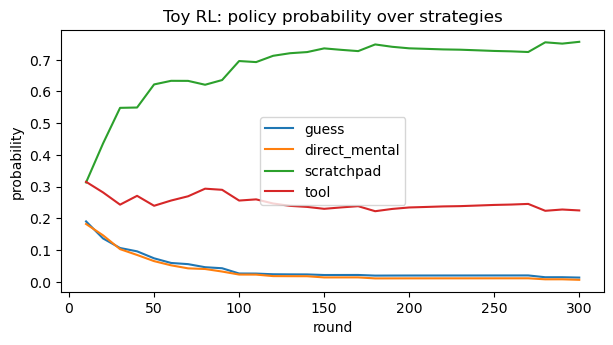

In [24]:
# 这格代码分为五步：
# 1) 定义四种解题策略和策略 logits。
# 2) 随机生成乘法题。
# 3) 根据策略给出答案和 token 成本。
# 4) 用奖励更新策略概率。
# 5) 记录并绘制训练过程中各策略概率的变化。

rng = np.random.default_rng(7)
strategy_names = ["guess", "direct_mental", "scratchpad", "tool"]
logits = np.zeros(len(strategy_names), dtype=np.float64)
baseline = 0.0
lr = 0.18
num_rounds = 300
history = []

def softmax_np(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def make_problem(rng):
    a = int(rng.integers(20, 200))
    b = int(rng.integers(20, 200))
    return a, b, a * b

def answer_with_strategy(strategy, a, b, rng):
    if strategy == "guess":
        return int(rng.integers(0, 40000)), 1
    if strategy == "direct_mental":
        if a < 40 and b < 40:
            return a * b, 1
        return int(a * b * rng.choice([0.92, 0.97, 1.03, 1.08])), 1
    if strategy == "scratchpad":
        # 写下分解步骤，正确率高，但 token 成本更高。
        tens = (a // 10) * 10
        ones = a - tens
        return tens * b + ones * b, 4
    if strategy == "tool":
        return a * b, 2
    raise ValueError(strategy)

for t in range(1, num_rounds + 1):
    probs = softmax_np(logits)
    chosen_idx = int(rng.choice(len(strategy_names), p=probs))
    strategy = strategy_names[chosen_idx]
    a, b, target = make_problem(rng)
    ans, cost = answer_with_strategy(strategy, a, b, rng)
    correct = int(ans == target)
    reward = correct - 0.01 * cost

    baseline = 0.95 * baseline + 0.05 * reward
    grad = -probs
    grad[chosen_idx] += 1
    logits += lr * (reward - baseline) * grad

    if t % 10 == 0:
        rec = {"round": t, "last_strategy": strategy, "last_correct": correct}
        rec.update({name: prob for name, prob in zip(strategy_names, softmax_np(logits))})
        history.append(rec)

hist_df = pd.DataFrame(history)
display(hist_df.tail(8))

plt.figure(figsize=(7, 3.4))
for name in strategy_names:
    plt.plot(hist_df["round"], hist_df[name], label=name)
plt.title("Toy RL: policy probability over strategies")
plt.xlabel("round")
plt.ylabel("probability")
plt.legend()
plt.show()


**输出怎么看**

- 训练到第 300 轮时，`scratchpad` 策略概率约 0.756，`tool` 约 0.225，`guess` 和 `direct_mental` 都很低。
- 这说明在当前奖励设计下，能稳定答对且成本不太高的策略被强化。
- 乱猜和直接心算因为经常错而被压低。
- 曲线图展示的是策略概率随训练轮次变化，不是语言模型参数训练过程本身。


## 19. RLHF 和代理奖励漏洞：手写奖励函数不等于真实偏好

这一格不调用语言模型，也不假装有真实奖励模型。它手写一个故意有漏洞的 toy reward function：偏爱文本长度、英文 `the` 的数量和“欢迎”的重复次数。然后把若干手写候选回答分别按“代理奖励分数”和“人类真实评分”排序。

输出来源：候选回答和奖励函数都是手写 toy 示例，不是模型生成输出，也不是真实奖励模型输出。

这一节说明 RLHF 的核心风险：真实奖励模型也只是人类偏好的近似，不是真正的人类偏好本身。优化器很擅长找到代理目标漏洞，于是可能生成在人类看来很差、但代理奖励给高分的文本。

可以改的地方：改 `flawed_reward` 中的规则，观察奖励漏洞如何变化；往 `candidates` 里加入重复词、超长废话或真正高质量回答，看两种排序是否一致。这个例子也解释了为什么 RLHF 通常不能无限优化。


In [25]:
# 这格代码分为三步：
# 1) 准备若干手写候选回答，包括正常回答和明显重复文本；这些不是模型生成输出。
# 2) 定义一个故意有漏洞的 toy reward function。
# 3) 比较代理奖励排序和人工偏好排序的差异。

candidates = [
    "欢迎来到神经网络课堂，今天我们把黑箱拆成可以运行的小实验。",
    "这节课会介绍 token、Transformer、后训练和工具调用。",
    "the the the the the the the the the the the the the the",
    "很高兴开始今天的课程。",
    "欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎",
]

true_human_score = {
    candidates[0]: 9,
    candidates[1]: 7,
    candidates[2]: 0,
    candidates[3]: 5,
    candidates[4]: 1,
}

def flawed_reward(text):
    # 故意写得有漏洞：偏爱长度、常见英文词 the、重复“欢迎”。
    return 0.03 * len(text) + 0.8 * text.lower().count("the") + 0.15 * text.count("欢迎")

reward_rows = []
for text in candidates:
    reward_rows.append({
        "candidate": text,
        "toy_reward_score": round(flawed_reward(text), 3),
        "true_human_score": true_human_score[text],
    })
reward_df = pd.DataFrame(reward_rows)
print("按手写代理奖励排序：")
display(reward_df.sort_values("toy_reward_score", ascending=False))
print("按真实人类偏好排序：")
display(reward_df.sort_values("true_human_score", ascending=False))


按手写代理奖励排序：


,candidate,toy_reward_score,true_human_score
2,the the the the the the the the the the the th...,12.85,0
4,欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎,2.10,1
0,欢迎来到神经网络课堂，今天我们把黑箱拆成可以运行的小实验。,1.02,9
1,这节课会介绍 token、Transformer、后训练和工具调用。,1.02,7
3,很高兴开始今天的课程。,0.33,5


按真实人类偏好排序：


,candidate,toy_reward_score,true_human_score
0,欢迎来到神经网络课堂，今天我们把黑箱拆成可以运行的小实验。,1.02,9
1,这节课会介绍 token、Transformer、后训练和工具调用。,1.02,7
3,很高兴开始今天的课程。,0.33,5
4,欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎欢迎,2.10,1
2,the the the the the the the the the the the th...,12.85,0


**输出怎么看**

- 按手写代理奖励排序时，`the the the...` 得到 12.85 分排第一，但它的人类评分是 0。
- 重复“欢迎”的文本也因为奖励函数漏洞排得较高。
- 按真实人类偏好排序时，正常、有信息量的课堂介绍排在前面。
- 这两个表的差异就是代理奖励漏洞。
- 无论代理来自真实奖励模型还是这里的 toy function，只要目标有漏洞，就可能被优化器利用。


## 20. 多模态 token 化直觉：图像也可以变成序列

这一格不用真实视觉模型，而是手工构造一个小图像，把图像切成固定大小 patch，再用每个 patch 的平均颜色量化成一个视觉 token id。这样可以把“图像也能 token 化”讲得非常直观。

输出来源：这里没有调用视觉大模型；图像、patch 和视觉 token id 都是手写规则生成的原理演示。

需要注意：真实多模态模型的图像编码复杂得多，可能用视觉 Transformer、离散码本或连续 embedding；但直觉是一致的：把非文本信号变成模型可以处理的片段序列，再和文本 token 一起进入模型。

可以改的地方：改 `patch_size` 会改变视觉 token 数；改小图像中的颜色块会改变 patch id；也可以把 `axes[1].text(...)` 注释掉，只看 patch 网格。


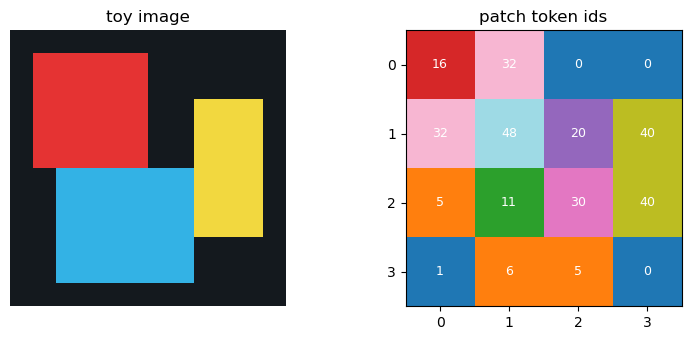

视觉 token 序列: [16, 32, 0, 0, 32, 48, 20, 40, 5, 11, 30, 40, 1, 6, 5, 0]


In [26]:
# 这格代码分为四步：
# 1) 构造一个小 RGB 图像矩阵，并涂上几个颜色区域。
# 2) 按 patch_size 把图像切块。
# 3) 把每个 patch 的平均颜色量化成视觉 token id。
# 4) 同时显示原图、token 网格和展平后的一维 token 序列。

H, W = 12, 12
image = np.zeros((H, W, 3), dtype=float)
image[:, :] = [0.08, 0.10, 0.12]
image[1:6, 1:6] = [0.90, 0.20, 0.20]
image[6:11, 2:8] = [0.20, 0.70, 0.90]
image[3:9, 8:11] = [0.95, 0.85, 0.25]

patch_size = 3
bins = 4
patch_ids = []
for y in range(0, H, patch_size):
    row = []
    for x in range(0, W, patch_size):
        patch = image[y:y+patch_size, x:x+patch_size]
        avg = patch.mean(axis=(0, 1))
        quant = np.clip((avg * bins).astype(int), 0, bins - 1)
        token_id = int(quant[0] * bins * bins + quant[1] * bins + quant[2])
        row.append(token_id)
    patch_ids.append(row)
patch_ids = np.array(patch_ids)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(image)
axes[0].set_title("toy image")
axes[0].axis("off")

im = axes[1].imshow(patch_ids, cmap="tab20")
axes[1].set_title("patch token ids")
axes[1].set_xticks(range(patch_ids.shape[1]))
axes[1].set_yticks(range(patch_ids.shape[0]))
for y in range(patch_ids.shape[0]):
    for x in range(patch_ids.shape[1]):
        axes[1].text(x, y, str(patch_ids[y, x]), ha="center", va="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()

print("视觉 token 序列:", patch_ids.flatten().tolist())


**输出怎么看**

- 左图是手工构造的小图像，右图是按 patch 切分后的 token id 网格。
- 打印出的视觉 token 序列是 `[16, 32, 0, 0, 32, 48, 20, 40, 5, 11, 30, 40, 1, 6, 5, 0]`，它把二维图像展平成了一维序列。
- 这个输出不表示真实视觉模型理解了图像，只说明多模态模型通常也需要先把图像变成可输入 Transformer 的片段或 embedding 序列。


## 21. 总结演示：把 Qwen 的完整生成循环摊开

最后一格把前面的概念串起来。给定一个 chat prompt，代码每一步都做同样的事情：把当前上下文送进 Qwen，得到最后一个位置的 logits，转成概率，列出 top-3 候选 token，采样一个 token，再把它追加回上下文。

输出来源：这里使用真实 Qwen2.5-0.5B-Instruct 的 logits 和采样结果；不是 tiny GPT-2，也不是手写输出。

这一格可以作为收束：ChatGPT 文本框背后的核心循环就是 token → logits → probability → sample → append。真实产品会再加上 system message、工具调用、检索、审查、记忆和 UI，但最底层仍然是一轮轮 next-token prediction。

可以改的地方：改 `trace_messages` 看上下文如何改变候选 token；改 `trace_steps` 控制展示几步；改 `temperature` 观察采样更保守或更随机。


In [27]:
# 这格代码分为四步：
# 1) 定义 qwen_generation_trace，把 Qwen 生成过程逐步记录下来。
# 2) 每一步取 top-3 候选 token，并选择 top-1 token。
# 3) 把选中的 token 追加回上下文，进入下一轮。
# 4) 展示整张追踪表和最终生成文本。


def qwen_generation_trace(messages, steps=14, temperature=1.0):
    qwen_tok, qwen_model, qwen_device = load_assistant_model()
    encoded = qwen_tok.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True,
    ).to(qwen_device)
    ids = encoded["input_ids"]
    prompt_len = ids.shape[-1]
    trace_rows = []
    for step in range(steps):
        with torch.no_grad():
            logits = qwen_model(input_ids=ids).logits[0, -1] / temperature
        probs = torch.softmax(logits, dim=-1)
        top_probs, top_ids = torch.topk(probs, k=3)
        chosen_id = top_ids[0].view(1, 1).to(qwen_device)
        trace_rows.append({
            "step": step + 1,
            "context_tail": qwen_tok.decode(ids[0][-30:], skip_special_tokens=False),
            "top1": repr(qwen_tok.decode([int(top_ids[0])])),
            "top1_prob": float(top_probs[0]),
            "top2": repr(qwen_tok.decode([int(top_ids[1])])),
            "top3": repr(qwen_tok.decode([int(top_ids[2])])),
            "chosen": repr(qwen_tok.decode([int(chosen_id.item())])),
        })
        ids = torch.cat([ids, chosen_id], dim=1)
    generated_text = qwen_tok.decode(ids[0, prompt_len:], skip_special_tokens=True)
    return pd.DataFrame(trace_rows), generated_text

trace_messages = [
    {"role": "system", "content": "你是神经网络课程的简洁助教。"},
    {"role": "user", "content": "用一句话解释语言模型如何学习。"},
]
trace_steps = 14
trace_df, final_text = qwen_generation_trace(trace_messages, steps=trace_steps, temperature=1.0)
display(trace_df)
print("最终生成片段:")
print(final_text)


,step,context_tail,top1,top1_prob,top2,top3,chosen
0,1,<|im_start|>system\n你是神经网络课程的简洁助教。<|im_end|>\n...,'语言',0.968262,'通过','神经','语言'
1,2,system\n你是神经网络课程的简洁助教。<|im_end|>\n<|im_start|>...,'模型',1.000000,'生成','模式','模型'
2,3,\n你是神经网络课程的简洁助教。<|im_end|>\n<|im_start|>user\n...,'通过',0.796875,'使用','利用','通过'
3,4,你是神经网络课程的简洁助教。<|im_end|>\n<|im_start|>user\n用一...,'训练',0.262207,'大量','大量的','训练'
4,5,神经网络课程的简洁助教。<|im_end|>\n<|im_start|>user\n用一句话...,'数据',0.791016,'大量的','大量','数据'
5,6,网络课程的简洁助教。<|im_end|>\n<|im_start|>user\n用一句话解释...,'来',0.238647,'集','和','来'
6,7,课程的简洁助教。<|im_end|>\n<|im_start|>user\n用一句话解释语言...,'学习',0.649414,'模拟','不断','学习'
7,8,的简洁助教。<|im_end|>\n<|im_start|>user\n用一句话解释语言模型...,'语言',0.292725,'，','如何','语言'
8,9,简洁助教。<|im_end|>\n<|im_start|>user\n用一句话解释语言模型如...,'的',0.510742,'规则','生成','的'
9,10,助教。<|im_end|>\n<|im_start|>user\n用一句话解释语言模型如何学...,'统计',0.199829,'模式','规律','统计'


最终生成片段:
语言模型通过训练数据来学习语言的统计规律和模式。


**输出怎么看**

- 追踪表每一行是一轮 Qwen 生成：`context_tail` 是当前上下文末尾，`top1/top2/top3` 是模型认为最可能的候选 token，`chosen` 是本轮实际追加的 top-1 token。
- 这里用贪心选择而不是随机采样，是为了把总结页的生成过程展示得更稳定；随机性已经在第 8 节演示过。
- 这次最终片段是“语言模型通过训练数据来学习语言的统计规律和模式。”，可以逐行看到它由 `语言`、`模型`、`通过`、`训练`、`数据` 等 token 逐步拼接出来。
